# M5 forecasting II: a hierarchical count state space model with

`numpyro_forecast`

This notebook continues the [M5 baselines
notebook](m5_forecasting.html), the port of the three [Pyro M5 Starter
Kit](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit) models to
`numpyro_forecast`, and asks what a real hierarchical model adds on the
same task: the 30,490 daily unit-sales series of the M5 competition
(3,049 items in 10 Walmart stores of 3 states), a 28-day horizon, and
the weighted scaled CRPS over the 42,840 series of the 12-level
hierarchy. On the evaluation window the kit’s top-down model scored a
WS-CRPS of 0.569, the middle-out model 0.634 and the bottom-up model
0.728, so the top-down model is the one to beat.

The candidate is a single **hierarchical count state space model** of
every item in every store, fitted with minibatch SVI: a negative
binomial likelihood with item-level dispersion, an item intercept
centered on the series’ level at the forecast origin, an end-anchored
random walk of the item level over 28-day blocks, daily store shocks
that sum to zero within every week, zero-sum weekday effects per
store-department with zero-sum item deviations, SNAP and calendar-event
effects and yearly seasonality, all partially pooled across the
hierarchy. It is compared with the top-down baseline in the same harness
on the three backtest windows of the baselines notebook and on the
evaluation window, at every level, with the calibration of the bands
alongside the score.

This is the second of the two M5 notebooks; the data loader, the
hierarchy, the scoring functions and the baseline are described in the
first one and only summarized here.

## Prepare notebook

In [1]:
import warnings
from functools import partial
from time import perf_counter

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
import polars as pl
import scipy.sparse as sp
import xarray as xr
from jax import random
from numpyro.infer import SVI, Predictive, Trace_ELBO, init_to_median
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.svi import SVIRunResult
from numpyro.optim import optax_to_numpyro

from numpyro_forecast import (
    Horizon,
    backtest,
    draw_posterior,
    evaluate_forecast,
    forecast,
    predict,
    predict_in_sample,
    predictions_to_datatree,
    results_to_dataframe,
)
from numpyro_forecast.datasets import load_m5
from numpyro_forecast.features import fourier_features
from numpyro_forecast.metrics import crps_empirical
from numpyro_forecast.typing import Array, ForecastFn, ForecastModel, Metric

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
numpyro.set_host_device_count(n=4)
rng_key = random.PRNGKey(seed=42)

pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_hide_column_data_types(True)
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(12)
pl.Config.set_tbl_width_chars(160)

# `predict` observes a (time, series) array under the series plate; the time axis is not a
# plate, so numpyro cannot check it and warns at every trace.
warnings.filterwarnings("ignore", message="Missing a plate statement for batch dimension -2")
# The second `plot_lm` call of an overlay reuses the alpha of the first one.
warnings.filterwarnings("ignore", message="When multiple credible intervals are plotted")

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Read data

`load_m5()` downloads the [Nixtla
mirror](https://github.com/Nixtla/m5-forecasts) of the competition files
once and reads them: the daily sales over the training period (`d_1` to
`d_1941`) followed by the 28 evaluation days (`d_1942` to `d_1969`), the
weekly shelf price of every series repeated over its days (`NaN` when
the item was not on the shelf), the series identifiers, the calendar and
the official evaluation weights. The calendar carries two event columns;
the second one is rare, but one of its five days (Father’s Day 2016)
falls inside the evaluation window, so both are indexed.

In [2]:
m5 = load_m5()

KEYS = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]
N_DAYS_TRAIN = 1_941
HORIZON = 28
N_DAYS = N_DAYS_TRAIN + HORIZON
sales = m5.sales
price = m5.price
keys_df = m5.keys
n_series = sales.shape[1]


def is_christmas() -> pl.Expr:
    """Flag December 25, the one day a year every Walmart store is closed."""
    return pl.col("date").dt.month().eq(pl.lit(12)).and_(pl.col("date").dt.day().eq(pl.lit(25)))


def day_of_week_index() -> pl.Expr:
    """Index the weekday from 0 (Monday) to 6 (Sunday)."""
    return pl.col("date").dt.weekday().sub(pl.lit(1))


def event_index(column: str, names: list[str]) -> pl.Expr:
    """Index an event column by its position in ``names``, 0 when there is no event."""
    return pl.col(column).replace_strict(names, list(range(1, len(names) + 1)), default=0)


event_names = sorted(
    set(m5.calendar["event_name_1"].drop_nulls().to_list())
    | set(m5.calendar["event_name_2"].drop_nulls().to_list())
)
calendar_df = (
    m5.calendar.lazy()
    .with_row_index("t")
    .with_columns(
        christmas=is_christmas().cast(pl.Float32),
        dow=day_of_week_index(),
        event_1=event_index("event_name_1", event_names),
        event_2=event_index("event_name_2", event_names),
    )
    .select("t", "date", "dow", "christmas", "event_1", "event_2", "snap_CA", "snap_TX", "snap_WI")
    .collect(engine="streaming")
)
print(f"{n_series} series over {N_DAYS} days, {len(event_names)} event names")
calendar_df.filter(pl.col("event_2").gt(0))

30490 series over 1969 days, 30 event names

### The hierarchy

The competition scores 42,840 series: the 30,490 items in stores (level
12) and their sums over the 11 coarser groupings. A label and a dense
group id per level turn into a sparse `(30,490, 42,840)` summation
matrix, so any array of bottom-level values (data or forecast draws) is
aggregated to every level with one sparse product. The store, department
and store-department ids of every series index the pooled parameters of
the model.

In [3]:
LEVELS: dict[str, list[str]] = {
    "Level1": [],
    "Level2": ["state_id"],
    "Level3": ["store_id"],
    "Level4": ["cat_id"],
    "Level5": ["dept_id"],
    "Level6": ["state_id", "cat_id"],
    "Level7": ["state_id", "dept_id"],
    "Level8": ["store_id", "cat_id"],
    "Level9": ["store_id", "dept_id"],
    "Level10": ["item_id"],
    "Level11": ["state_id", "item_id"],
    "Level12": ["item_id", "store_id"],
}


def level_label(columns: list[str]) -> pl.Expr:
    """Label of the aggregate a series belongs to at one level, ``Agg_Level_1/Agg_Level_2``."""
    parts = [pl.col(column) for column in columns] or [pl.lit("Total")]
    if len(parts) == 1:
        parts.append(pl.lit("X"))
    return pl.concat_str(parts, separator="/")


def group_id(label: str) -> pl.Expr:
    """Dense 0-based id of the aggregate named by ``label``, in sorted label order."""
    return pl.col(label).rank("dense").cast(pl.Int64).sub(pl.lit(1))


def add_level_ids(keys: pl.DataFrame) -> pl.DataFrame:
    """Add one label and one group id column per M5 level."""
    return keys.with_columns(
        **{f"{level}_label": level_label(columns) for level, columns in LEVELS.items()}
    ).with_columns(**{level: group_id(f"{level}_label") for level in LEVELS})


def aggregation_matrix(
    hierarchy: pl.DataFrame,
) -> tuple[sp.csr_matrix, list[str], dict[str, slice]]:
    """Sparse ``(n_series, n_aggregates)`` sum matrix over the 12 levels, with labels and slices."""
    rows, cols, labels, slices = [], [], [], {}
    offset = 0
    for level in LEVELS:
        rows.append(np.arange(hierarchy.height))
        cols.append(offset + hierarchy[level].to_numpy())
        level_labels = (
            hierarchy.select(f"{level}_label", level)
            .unique()
            .sort(level)[f"{level}_label"]
            .to_list()
        )
        labels += [f"{level}/{label}" for label in level_labels]
        slices[level] = slice(offset, offset + len(level_labels))
        offset += len(level_labels)
    values = np.ones(hierarchy.height * len(LEVELS), dtype=np.float32)
    matrix = sp.csr_matrix(
        (values, (np.concatenate(rows), np.concatenate(cols))), shape=(hierarchy.height, offset)
    )
    return matrix, labels, slices


hierarchy_df = keys_df.pipe(add_level_ids)
agg_matrix, agg_labels, level_slices = aggregation_matrix(hierarchy_df)
sales_agg = sales @ agg_matrix
store_ids = [
    label.removeprefix("Level3/").removesuffix("/X")
    for label in agg_labels[level_slices["Level3"]]
]
dept_ids = [
    label.removeprefix("Level5/").removesuffix("/X")
    for label in agg_labels[level_slices["Level5"]]
]
group_ids = [label.removeprefix("Level9/") for label in agg_labels[level_slices["Level9"]]]
state_index = hierarchy_df["Level2"].to_numpy()
store_index = jnp.asarray(hierarchy_df["Level3"].to_numpy(), dtype=jnp.int32)
dept_index = jnp.asarray(hierarchy_df["Level5"].to_numpy(), dtype=jnp.int32)
group_index = jnp.asarray(hierarchy_df["Level9"].to_numpy(), dtype=jnp.int32)
N_STORES, N_DEPTS, N_GROUPS = len(store_ids), len(dept_ids), len(group_ids)
print(
    f"aggregation matrix {agg_matrix.shape}: {N_STORES} stores, {N_DEPTS} departments, {N_GROUPS} store-departments"
)

aggregation matrix (30490, 42840): 10 stores, 7 departments, 70 store-departments

## Scoring at every level

The score is the one of the baselines notebook. For a series $s$ at
level $\ell$, $c_s$ is the mean CRPS of its 28-day forecast, $w_s$ its
share of the dollar sales of the level over the 28 days before the
forecast origin and $\sigma_s$ its scale, the mean absolute lag-one
difference of the training series after its first nonzero value:

$$
\text{WS-CRPS} = \frac{1}{12} \sum_{\ell=1}^{12} \sum_{s \in \ell} w_s \frac{c_s}{\sigma_s}.
$$

The functions plug into `backtest()`: a `transform` sums the
bottom-level draws and the truth to the 42,840 series and
`per_window_metrics` returns one weighted scaled CRPS per level for the
window’s origin. Besides the mean over the 12 levels we report the means
over levels 1 to 9 (the aggregates) and 10 to 12 (the items), because
the two halves reward different things: calibrated common uncertainty at
the top, a sharp level per item at the bottom. Four coverage metrics
(the share of series-days inside the central $94\%$ interval of the
draws at levels 1, 3, 9 and 12) come along, because a CRPS alone does
not say whether a model is sharp or just narrow. The competition’s
pinball loss (WSPL) is reported on the evaluation window.

In [4]:
christmas = calendar_df["christmas"].to_numpy()[:N_DAYS]
saled = (~np.isnan(price)).astype(np.float32) * (1.0 - christmas[:, None])
price_filled = np.nan_to_num(price, nan=0.0)


def m5_weights(t1: int) -> np.ndarray:
    """Dollar-sales share of every aggregate over the 28 days before ``t1``, normalized per level."""
    dollars = (sales[t1 - 28 : t1] * price_filled[t1 - 28 : t1]).sum(0) @ agg_matrix
    weights = np.empty_like(dollars)
    for level_slice in level_slices.values():
        weights[level_slice] = dollars[level_slice] / dollars[level_slice].sum()
    return weights


def m5_scales(y: np.ndarray) -> np.ndarray:
    """Mean absolute lag-1 difference of every column of ``y`` over its active period.

    The active period starts at the first nonzero value; the jump from zero on that day is
    excluded, the sum of absolute differences is clamped at one and divided by the number of
    active days minus one (the kit's ``get_metric_scale("pl", ...)``).
    """
    duration, n_columns = y.shape
    active = np.maximum((np.cumsum(y, axis=0) != 0).sum(0), 2)
    start_value = y[duration - active, np.arange(n_columns)]
    lag1_norm = np.abs(np.diff(y, axis=0, prepend=0.0)).sum(0) - np.abs(start_value)
    return np.maximum(lag1_norm, 1.0) / (active - 1)


def aggregate_transform(
    pred: np.ndarray | Array, truth: np.ndarray | Array
) -> tuple[np.ndarray, np.ndarray]:
    """Sum bottom-level draws and truth to the 42,840 aggregates of the 12 M5 levels."""
    n = pred.shape[-1]
    pred_levels = np.asarray(pred, dtype=np.float32).reshape(-1, n) @ agg_matrix
    truth_levels = np.asarray(truth, dtype=np.float32) @ agg_matrix
    return pred_levels.reshape(*pred.shape[:-1], -1), truth_levels


def ws_crps_level(
    pred: Array, truth: Array, *, level_slice: slice, weights: np.ndarray, scales: np.ndarray
) -> Array:
    """Weighted scaled CRPS of one level: weight times mean CRPS over the horizon, over scale."""
    crps = crps_empirical(pred[..., level_slice], truth[..., level_slice]).mean(axis=0)
    return jnp.sum(jnp.asarray(weights) * crps / jnp.asarray(scales))


def coverage_level(pred: Array, truth: Array, *, level_slice: slice, prob: float = 0.94) -> Array:
    r"""Share of the series-days of one level inside the central $94\%$ interval of the draws."""
    tail = (1.0 - prob) / 2.0
    lower, upper = np.quantile(np.asarray(pred[..., level_slice]), [tail, 1.0 - tail], axis=0)
    actual = np.asarray(truth[..., level_slice])
    return jnp.asarray(np.mean((actual >= lower) & (actual <= upper)))


COVERAGE_LEVELS = ["Level1", "Level3", "Level9", "Level12"]


def m5_metrics(t0: int, t1: int, t2: int) -> dict:
    r"""Build the 12 weighted scaled CRPS metrics of a window whose training data ends at ``t1``.

    Four $94\%$ coverage metrics (levels 1, 3, 9 and 12) come along to read the calibration.
    """
    weights = m5_weights(t1)
    scales = m5_scales(sales_agg[:t1])
    metrics: dict[str, Metric] = {
        f"ws_crps_{level}": partial(
            ws_crps_level,
            level_slice=level_slice,
            weights=weights[level_slice],
            scales=scales[level_slice],
        )
        for level, level_slice in level_slices.items()
    }
    for level in COVERAGE_LEVELS:
        metrics[f"coverage_{level}"] = partial(coverage_level, level_slice=level_slices[level])
    return metrics


M5_QUANTILES = np.array(
    [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995], dtype=np.float32
)


def ws_pinball(
    pred_levels: np.ndarray, truth_levels: np.ndarray, weights: np.ndarray, scales: np.ndarray
) -> float:
    """M5 WSPL: pinball loss at the nine competition quantiles, weighted, scaled, mean over levels."""
    quantiles = np.quantile(pred_levels, M5_QUANTILES, axis=0)
    error = quantiles - truth_levels[None]
    u = M5_QUANTILES[:, None, None]
    per_series = (np.where(error <= 0, -u, 1 - u) * error).mean(axis=(0, 1))
    level_scores = [
        np.sum(weights[level_slice] * per_series[level_slice] / scales[level_slice])
        for level_slice in level_slices.values()
    ]
    return float(np.mean(level_scores))


LEVEL_COLUMNS = [f"metric_ws_crps_{level}" for level in LEVELS]
TOP_LEVELS = LEVEL_COLUMNS[:9]
ITEM_LEVELS = LEVEL_COLUMNS[9:]
COVERAGE_COLUMNS = [f"metric_coverage_{level}" for level in COVERAGE_LEVELS]


def summarize_backtest(results: list, name: str) -> pl.DataFrame:
    """One row per window with the mean WS-CRPS over all levels, levels 1 to 9 and levels 10 to 12."""
    return (
        pl.from_pandas(results_to_dataframe(results))
        .with_columns(
            model=pl.lit(name),
            ws_crps=pl.mean_horizontal(LEVEL_COLUMNS),
            ws_crps_1_9=pl.mean_horizontal(TOP_LEVELS),
            ws_crps_10_12=pl.mean_horizontal(ITEM_LEVELS),
        )
        .select(
            "model",
            "t1",
            "t2",
            "walltime",
            "ws_crps",
            "ws_crps_1_9",
            "ws_crps_10_12",
            *LEVEL_COLUMNS,
            *COVERAGE_COLUMNS,
        )
    )

## Features

The model sees three per-series channels stacked with time at axis $-2$:
the day index (through which the calendar tables are looked up inside
the model), the `saled` flag (price listed and not Christmas, which
gates the mean as in the kit) and the log of the shelf price relative to
the item’s mean listed price over the first 1,843 days (the first
backtest origin, so the reference never uses later data). The price
channel is carried for the reader who wants to add an elasticity; the
model below does not use it, for a reason given with the ablation. Sixty
nonzero sales on days without a listed price or on a closed Christmas
are set to zero in the training counts, since the model puts the mean at
its floor on those days. The calendar tables (weekday, SNAP by state,
the two event indices and four yearly Fourier harmonics) live outside
the tensor.

In [5]:
REFERENCE_DAYS = N_DAYS_TRAIN - HORIZON - 2 * 35  # 1,843: the first backtest origin
BLOCK = 28
N_BLOCKS = 13  # one year of 28-day blocks before the origin

listed_days = saled[:REFERENCE_DAYS].sum(0)
reference_price = np.nansum(price[:REFERENCE_DAYS], axis=0) / np.maximum(listed_days, 1.0)
log_price_ratio = np.nan_to_num(
    np.log(price / np.where(listed_days > 0, reference_price, 1.0)), nan=0.0
).astype(np.float32)
covariates_np = np.empty((3, N_DAYS, n_series), dtype=np.float32)
covariates_np[0] = np.arange(N_DAYS, dtype=np.float32)[:, None]
covariates_np[1] = saled
covariates_np[2] = log_price_ratio
covariates = jnp.asarray(covariates_np)
del covariates_np
y_counts = jnp.asarray(np.rint(sales * saled).astype(np.int32))  # nothing sells on a closed day

dow_table = jnp.asarray(calendar_df["dow"].to_numpy()[:N_DAYS], dtype=jnp.int32)
snap_table = jnp.asarray(
    calendar_df.select("snap_CA", "snap_TX", "snap_WI").to_numpy()[:N_DAYS], dtype=jnp.float32
)
event_tables = (
    jnp.asarray(calendar_df["event_1"].to_numpy()[:N_DAYS], dtype=jnp.int32),
    jnp.asarray(calendar_df["event_2"].to_numpy()[:N_DAYS], dtype=jnp.int32),
)
N_EVENTS = len(event_names) + 1
N_HARMONICS = 4
fourier_table = jnp.asarray(fourier_features(N_DAYS, 365.25, N_HARMONICS), dtype=jnp.float32)
state_of_store = jnp.asarray(
    [state_index[np.argmax(np.asarray(store_index) == s)] for s in range(N_STORES)],
    dtype=jnp.int32,
)
n_zeroed = int((sales * (1 - saled) > 0).sum())
print(
    f"covariates {covariates.shape}, {covariates.nbytes / 1e9:.2f} GB; "
    f"{n_zeroed} nonzero sales on unlisted or closed days set to 0"
)

covariates (3, 1969, 30490), 0.72 GB; 60 nonzero sales on unlisted or closed days set to 0

## The model

For item $i$ in store $r(i)$, department $d(i)$ and store-department
$j(i)$ (70 groups), on day $t$ with weekday $w(t)$, 28-day block $b(t)$
(counted so that the horizon is one whole block), calendar events
$e_1(t)$ and $e_2(t)$ and yearly Fourier terms $\mathbf{f}_t$:

$$
\begin{align*}
y_{i,t} &\sim \text{NegativeBinomial2}\big(\text{saled}_{i,t}\, e^{\eta_{i,t}},\ \phi_i\big), \qquad \log \phi_i \sim \text{Normal}(\log \phi_{j(i)}, \tau_{d(i)}), \\
\eta_{i,t} &= \log m_i + \alpha_i + u_{i,b(t)} + \epsilon_{r(i),t} + s_{j(i),w(t)} + \tilde s_{i,w(t)} + \beta_{j(i)}\,\text{snap}_{r(i),t} + \mathbf{w}_{d(i)}^\top \mathbf{f}_t + \gamma_{d(i),e_1(t)} + \gamma_{d(i),e_2(t)}.
\end{align*}
$$

- **Level at the origin.** $m_i$ is the item’s mean sales over its
  listed days of the last 28 training days (falling back to the last
  year, then to a floor) and
  $\alpha_i \sim \text{Normal}(0, \sigma^{\alpha}_{d(i)})$ a partially
  pooled deviation from it. With the walk anchored at zero on the last
  training block, $\log m_i + \alpha_i$ is the log level at the forecast
  origin: the share heuristic of the kit becomes the prior center of a
  Bayesian item level.
- **Item block walk** $u_{i,b}$: a random walk over the last 13 blocks
  of 28 days, end-anchored (zero on the last block, earlier blocks minus
  the innovations that follow them) with a department-level innovation
  scale; the horizon block adds one fresh innovation. This is the local
  level of a state space model, at the resolution a single item series
  can support.
- **Weekly store shocks** $\epsilon_{r,t}$: daily shocks shared by every
  item of a store that sum to zero within each week (`ZeroSumNormal`
  over the seven days, weeks counted back from the origin). A zero-sum
  week cannot absorb a level change, so the shocks carry only the common
  day-to-day variation of a store; their fresh future weeks give
  correlated uncertainty to the aggregates.
- **Weekday**: `ZeroSumNormal` effects $s_{j,\cdot}$ per
  store-department and zero-sum item deviations
  $\tilde s_{i,\cdot} = \sigma^{s}_{d(i)} z_i$ with
  $z_i \sim \text{ZeroSumNormal}(1)$ (the distribution does not take a
  per-item scale).
- **Calendar**: SNAP per store-department, one effect per department and
  event name with a shared shrinkage scale, four yearly harmonics with
  department-level weights.
- **Likelihood**: negative binomial with an item-level dispersion pooled
  to the store-department. The log mean is clipped at $\log 2{,}000$; no
  series sells more than 763 units on a day.

The model is one function of `(covariates, data)` on `Horizon.from_data`
and `predict()`. The item-level sites sit inside the `series` plate,
which the guide subsamples with `create_plates` (1,500 series per step);
`numpyro.subsample` picks the matching columns of the data, the
covariates, the index arrays and the origin levels, and the observed log
density is scaled by $30{,}490 / 1{,}500$. The block and week sites use
explicit plates at `dim=-2` instead of `innovations()`, because
`AutoNormal` keeps one size per plate name and the daily `time` plate is
already taken by `predict()`. With `forecast_only=True` the same
function evaluates the item terms over the horizon rows only and exposes
the horizon mean and dispersion as deterministic sites: that is how the
notebook draws the 30,490-series forecast, because the
`NegativeBinomial2` sampler behind `forecast()` (a Gamma and a Poisson
draw in JAX) costs minutes per window on this CPU where NumPy needs
seconds. `forecast()` itself is used on the seven focus items for the
plots.

### Why these components

The model was built up one component at a time during development, with
the same code, on a selection window whose forecast origin is day 1,878
(250 draws, a second SVI seed of one variant moved the score by 0.002).
The table is the ablation that chose the components; it is not re-run in
this notebook.

| model (origin day 1,878) | WS-CRPS | levels 1 to 9 | levels 10 to 12 |
|------------------|------------------|------------------|------------------|
| top-down (kit) | 0.553 | 0.481 | 0.767 |
| Poisson, intercepts centered on the origin level | 0.893 | 0.865 | 0.975 |
| \+ item dispersion (negative binomial) | 0.846 | 0.812 | 0.950 |
| \+ item block walk | 0.537 | 0.457 | 0.778 |
| \+ yearly seasonality, events, item weekday deviations | 0.513 | 0.427 | 0.773 |
| \+ department price elasticity | 0.513 | 0.426 | 0.773 |
| \+ weekly store shocks, no price (**this notebook**) | 0.514 | 0.427 | 0.774 |
| \+ end-anchored store and store-department block walks instead of the shocks | 0.521 | 0.435 | 0.777 |

Three readings. Without a level process, a two-year intercept is the
wrong level for most items and the model loses to the baseline by a wide
margin: the block walk is the component that makes the item model work.
Yearly seasonality, events and item weekday deviations buy the next
0.024, almost all at the aggregate levels. The price elasticity changes
nothing (a per-item elasticity was tried first and is unidentified for
the many items whose price never moves), and shared block walks at the
store and store-department level cost 0.007: what a store’s level does
over 13 blocks is already in its items. The weekly shocks do not move
the CRPS, but they change the calibration: on the selection window the
$94\%$ coverage at level 1 went from 0.54 to 0.68, at level 3 from 0.70
to 0.95 and at level 9 from 0.81 to 0.90, with the items unchanged. They
are kept because a hierarchical forecast that is right on average but
wrong about its own uncertainty at the store level is not a state space
model, and the backtest below reports the coverage so the reader can
judge.

In [6]:
SUBSAMPLE_SIZE = 1_500
HISTORY_DAYS = 730  # the model trains on the last two years before the forecast origin
MAX_LOG_MEAN = float(np.log(2_000.0))  # no series sells more than 763 units on a day


def block_index(h: Horizon) -> Array:
    """Index of the 28-day block of every day, counted so that the horizon is block ``N_BLOCKS``.

    The last training block ends at the forecast origin; days more than ``N_BLOCKS`` blocks
    before the origin share block 0.
    """
    t = jnp.arange(h.duration)
    return jnp.clip((t - h.t_obs) // BLOCK + N_BLOCKS, 0, N_BLOCKS)


def block_walk(name: str, scale: Array, h: Horizon) -> Array:
    """Random walk over 28-day blocks that is zero on the last training block.

    Earlier blocks are minus the innovations that follow them, so the intercepts carry the
    level at the origin; when forecasting, one more innovation moves the horizon block. The
    site is sampled under a ``block`` plate at ``dim=-2`` and inherits the enclosing
    (subsampled) series plate.
    """
    with numpyro.plate(f"{name}_blocks", N_BLOCKS - 1, dim=-2):
        drift = numpyro.sample(name, dist.Normal(0.0, scale))
    walk = jnp.concatenate(
        [-jnp.flip(jnp.cumsum(jnp.flip(drift, 0), 0), 0), jnp.zeros_like(drift[:1])]
    )
    if h.future > 0:
        with numpyro.plate(f"{name}_future_blocks", 1, dim=-2):
            future = numpyro.sample(f"{name}_future", dist.Normal(0.0, scale))
        walk = jnp.concatenate([walk, future], axis=0)
    return walk


def weekly_shocks(name: str, scale: Array, h: Horizon, size: int) -> Array:
    """Daily shocks that sum to zero within every week, one week per row.

    A zero-sum week cannot absorb a level change, so the shocks carry only the common
    day-to-day variation of the series that share them; the horizon gets fresh weeks.
    """
    n_weeks = -(-h.t_obs // 7)
    with numpyro.plate(f"{name}_weeks", n_weeks, dim=-2):
        shock = numpyro.sample(name, dist.ZeroSumNormal(1.0, event_shape=(7,)))
    if h.future > 0:
        with numpyro.plate(f"{name}_future_weeks", (h.future + 6) // 7, dim=-2):
            future = numpyro.sample(f"{name}_future", dist.ZeroSumNormal(1.0, event_shape=(7,)))
        shock = jnp.concatenate([shock, future], axis=0)
    days = jnp.transpose(scale[:, None] * shock, (0, 2, 1)).reshape(-1, size)
    return days[n_weeks * 7 - h.t_obs :][: h.duration]  # weeks end at the origin


def make_model(
    level_at_origin: Array,
    *,
    store_index: Array = store_index,
    group_index: Array = group_index,
    dept_index: Array = dept_index,
    forecast_only: bool = False,
) -> ForecastModel:
    """Build the hierarchical negative binomial state space model of the M5 series.

    ``level_at_origin`` is the log of every series' mean sales over the last 28 listed
    training days: the prior center of the item intercepts, which the end-anchored walk
    makes the level at the forecast origin. With ``forecast_only=True`` the item-level terms
    are evaluated over the horizon rows only and exposed as the deterministic sites
    ``mean_future`` and ``concentration`` instead of the likelihood, which is how the
    notebook draws the 30,490-series forecast.
    """
    n_series = store_index.shape[0]

    def model(covariates: Array, data: Array | None = None) -> None:
        h = Horizon.from_data(covariates, data)
        t_index = covariates[0, :, 0].astype(jnp.int32)
        rows = slice(h.t_obs, None) if forecast_only else slice(None)
        dow = dow_table[t_index][rows]
        with numpyro.plate("dept", N_DEPTS):
            sigma_alpha = numpyro.sample("sigma_alpha", dist.HalfNormal(0.5))
            tau_phi = numpyro.sample("tau_phi", dist.HalfNormal(1.0))
            sigma_walk = numpyro.sample("sigma_walk", dist.HalfNormal(0.3))
            sigma_item_dow = numpyro.sample("sigma_item_dow", dist.HalfNormal(0.2))
            w_fourier = numpyro.sample(
                "w_fourier", dist.Normal(0.0, 0.3).expand([2 * N_HARMONICS]).to_event(1)
            )
            sigma_event = numpyro.sample("sigma_event", dist.HalfNormal(0.3))
            gamma_event = numpyro.sample(
                "gamma_event",
                dist.Normal(0.0, sigma_event[:, None]).expand([N_DEPTS, N_EVENTS]).to_event(1),
            )
        with numpyro.plate("store", N_STORES):
            store_shock_scale = numpyro.sample("store_shock_scale", dist.HalfNormal(0.05))
            store_shock = weekly_shocks("store_shock", store_shock_scale, h, N_STORES)
        with numpyro.plate("group", N_GROUPS):
            log_phi_group = numpyro.sample("log_phi_group", dist.Normal(0.0, 1.0))
            seasonal_group = numpyro.sample(
                "seasonal_group", dist.ZeroSumNormal(0.3, event_shape=(7,))
            )
            snap_group = numpyro.sample("snap_group", dist.Normal(0.0, 0.3))
        block = block_index(h)[rows]
        with numpyro.plate("series", n_series):
            batch = numpyro.subsample(covariates, event_dim=0)
            y = None if data is None else numpyro.subsample(data, event_dim=0)
            store = numpyro.subsample(store_index, event_dim=0)
            group = numpyro.subsample(group_index, event_dim=0)
            dept = numpyro.subsample(dept_index, event_dim=0)
            offset = numpyro.subsample(level_at_origin, event_dim=0)
            alpha = offset + numpyro.sample("alpha", dist.Normal(0.0, sigma_alpha[dept]))
            log_phi = numpyro.sample("log_phi", dist.Normal(log_phi_group[group], tau_phi[dept]))
            item_dow = sigma_item_dow[dept][:, None] * numpyro.sample(
                "item_dow", dist.ZeroSumNormal(1.0, event_shape=(7,))
            )
            eta = alpha + block_walk("item_walk", sigma_walk[dept], h)[block]
            eta = eta + store_shock[rows][:, store]
            eta = eta + seasonal_group[group][:, dow].T + item_dow[:, dow].T
            eta = eta + snap_group[group] * snap_table[t_index][rows][:, state_of_store[store]]
            eta = eta + fourier_table[t_index][rows] @ w_fourier[dept].T
            for event_table in event_tables:
                eta = eta + gamma_event[dept][:, event_table[t_index][rows]].T
            mean = batch[1][rows] * jnp.exp(jnp.clip(eta, -12.0, MAX_LOG_MEAN)) + 1e-6
            concentration = jnp.exp(log_phi)
            if forecast_only:
                numpyro.deterministic("mean_future", mean)
                numpyro.deterministic("concentration", concentration)
            else:
                predict(
                    Horizon.from_data(batch, y),
                    lambda m: dist.NegativeBinomial2(m, concentration),
                    mean,
                )

    return model


def create_series_plates(covariates: Array, data: Array | None = None) -> numpyro.plate:
    """Subsample the series plate in the guide; the model replays the same indices."""
    return numpyro.plate("series", n_series, subsample_size=SUBSAMPLE_SIZE)

## Fitting and forecasting

`AutoNormal` with the median initialization (the uniform default
overflows the exponential of a sum of ten log-scale terms), a one-cycle
Adam schedule peaking at 0.03 with clipped gradients, 3,000 steps over
the last two years of training data. Two years, rather than the five of
the baselines, halve the cost of a step and let every series be visited
about 150 times; a walk anchored at the origin has no use for older
history, and the yearly terms see two cycles.

The `backtest` closure receives the raw bottom-level sales of the
window, builds the training counts and the origin levels, fits, and
returns bottom-level draws: 50 posterior draws at a time, run through
the forecast-only model, sampled with NumPy, then discarded. The draws
are summed up the hierarchy by the scoring `transform`. The model
instance of the evaluation window is built here as well: its intercept
centers are the levels of the last 28 training days.

In [7]:
NUM_STEPS = 3_000
PEAK_LR = 0.03


def recent_level(train_counts: Array, train_saled: Array, days: int = BLOCK) -> Array:
    """Log of the mean sales of every series over its listed days of the last ``days`` days.

    Series with no listed day in that window fall back to the last 13 blocks (a year); series
    with no listed day at all get the floor.
    """
    listed_recent = train_saled[-days:].sum(0)
    mean_recent = train_counts[-days:].sum(0) / jnp.maximum(listed_recent, 1.0)
    listed_year = train_saled[-N_BLOCKS * BLOCK :].sum(0)
    mean_year = train_counts[-N_BLOCKS * BLOCK :].sum(0) / jnp.maximum(listed_year, 1.0)
    mean = jnp.where(listed_recent > 0, mean_recent, jnp.where(listed_year > 0, mean_year, 0.0))
    return jnp.log(mean + 0.05)


def fit_model(
    rng_key: Array,
    model: ForecastModel,
    train_covariates: Array,
    train_counts: Array,
    *,
    num_steps: int = NUM_STEPS,
) -> tuple[AutoNormal, SVIRunResult, float]:
    """Fit the model with subsampled SVI; return the guide, the result and the wall time."""
    guide = AutoNormal(model, init_loc_fn=init_to_median, create_plates=create_series_plates)
    schedule = optax.linear_onecycle_schedule(
        transition_steps=num_steps,
        peak_value=PEAK_LR,
        pct_start=0.2,
        pct_final=0.8,
        div_factor=10,
        final_div_factor=10,
    )
    optimizer = optax_to_numpyro(
        optax.chain(optax.clip_by_global_norm(10.0), optax.adam(schedule))
    )
    svi = SVI(model, guide, optimizer, Trace_ELBO())
    start = perf_counter()
    result = svi.run(rng_key, num_steps, train_covariates, train_counts, progress_bar=False)
    jax.block_until_ready(result.losses)
    return guide, result, perf_counter() - start


def forecast_bottom_level(
    rng_key: Array,
    guide: AutoNormal,
    params: dict,
    train_counts: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    chunk: int = 50,
) -> np.ndarray:
    """Draw ``num_samples`` bottom-level forecasts of every series, ``chunk`` posterior draws at a time.

    Each chunk draws the posterior, runs the forecast-only model for the horizon mean and
    dispersion of every series, and samples the negative binomial counts with NumPy.
    """
    model_fc = make_model(
        recent_level(train_counts, full_covariates[1][: train_counts.shape[0]]),
        forecast_only=True,
    )
    n_days = full_covariates.shape[1] - train_counts.shape[0]
    draws = np.empty((num_samples, n_days, train_counts.shape[1]), dtype=np.float32)
    generator = np.random.default_rng(int(rng_key[1]))
    for start in range(0, num_samples, chunk):
        key_post, key_pred = random.split(random.fold_in(rng_key, start))
        posterior = draw_posterior(key_post, guide, params, min(chunk, num_samples - start))
        pred = Predictive(model_fc, posterior, return_sites=["mean_future", "concentration"])(
            key_pred, full_covariates, train_counts
        )
        mean = np.asarray(pred["mean_future"], dtype=np.float64)
        concentration = np.asarray(pred["concentration"], dtype=np.float64)[:, None, :]
        draws[start : start + mean.shape[0]] = generator.negative_binomial(
            concentration, concentration / (concentration + mean)
        )
    return draws


def forecast_fn_item(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> np.ndarray:
    """`backtest` closure of the item model: build the counts and the levels, fit, forecast.

    ``model`` is not used: the intercept centers are the window's last-28-day levels, so
    the model instance is rebuilt from the training window.
    """
    key_fit, key_fc = random.split(rng_key)
    t1 = train_data.shape[0]
    train_covariates = train_covariates[:, -HISTORY_DAYS:]
    train_counts = jnp.rint(train_data[-HISTORY_DAYS:] * train_covariates[1]).astype(jnp.int32)
    model = make_model(recent_level(train_counts, train_covariates[1]))
    guide, result, _ = fit_model(key_fit, model, train_covariates, train_counts)
    return forecast_bottom_level(
        key_fc,
        guide,
        result.params,
        train_counts,
        full_covariates[:, t1 - HISTORY_DAYS :],
        num_samples,
    )


sales_train = jnp.asarray(sales[:N_DAYS_TRAIN])
covariates_final = covariates[:, N_DAYS_TRAIN - HISTORY_DAYS :]
counts_final = jnp.rint(sales_train[-HISTORY_DAYS:] * covariates_final[1, :HISTORY_DAYS]).astype(
    jnp.int32
)
level_final = recent_level(counts_final, covariates_final[1, :HISTORY_DAYS])
final_model = make_model(level_final)

## The baseline in the same harness

The kit’s top-down model (a StudentT regression on the log of the total
with a trend, weekday and day-of-month effects, split to the items with
their last-28-day shares and Poisson noise) is re-run in this notebook
with the same windows and the same number of draws, so the comparison is
exact; the other two baselines are quoted from the baselines notebook.

In [8]:
day_of_month = calendar_df["date"].dt.day().to_numpy()[:N_DAYS]
covariates_top = jnp.asarray(
    np.column_stack(
        [
            np.arange(N_DAYS, dtype=np.float32) / 365.0,
            calendar_df["dow"].to_numpy()[:N_DAYS].astype(np.float32),
            np.stack([(day_of_month == day).astype(np.float32) for day in range(1, 32)], axis=-1),
        ]
    )
)


def top_down_model(covariates: Array, data: Array | None = None) -> None:
    """Kit model 1: trend, weekday and day-of-month effects on the log of the total sales."""
    h = Horizon.from_data(covariates, data)
    time = covariates[:, 0]
    dow = covariates[:, 1].astype(jnp.int32)
    feature = covariates[:, 2:]
    bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
    trend = numpyro.sample("trend", dist.LogNormal(-2.0, 1.0))
    weight = numpyro.sample(
        "weight", dist.Normal(0.0, 1.0).expand([feature.shape[-1]]).to_event(1)
    )
    with numpyro.plate("day_of_week", 7):
        seasonal = numpyro.sample("seasonal", dist.Normal(0.0, 5.0))
    prediction = bias + trend * time + seasonal[dow] + feature @ weight
    dof = numpyro.sample("dof", dist.Uniform(1.0, 10.0))
    noise_scale = numpyro.sample("noise_scale", dist.LogNormal(-2.0, 1.0))
    predict(h, dist.StudentT(dof, 0.0, noise_scale), prediction[:, None])


def forecast_fn_top_down(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> np.ndarray:
    """Fit the kit's top-down model and split its forecast to the items with Poisson noise."""
    key_fit, key_post, key_fc = random.split(rng_key, 3)
    y = jnp.log(train_data.sum(-1, keepdims=True))
    guide = AutoNormal(model)
    schedule = optax.exponential_decay(0.1, transition_steps=1_001, decay_rate=0.1)
    optimizer = optax_to_numpyro(
        optax.chain(optax.clip_by_global_norm(10.0), optax.adam(schedule))
    )
    svi = SVI(model, guide, optimizer, Trace_ELBO())
    result = svi.run(key_fit, 1_001, train_covariates, y, progress_bar=False)
    posterior = draw_posterior(key_post, guide, result.params, num_samples)
    total = np.exp(np.asarray(forecast(key_fc, model, posterior, y, full_covariates)))
    last_28 = np.asarray(train_data[-28:]).sum(0)
    shares = (last_28 / last_28.sum()).astype(np.float32)
    generator = np.random.default_rng(int(train_data.shape[0]))
    draws = np.empty((num_samples, total.shape[1], shares.size), dtype=np.float32)
    for start in range(0, num_samples, 50):
        draws[start : start + 50] = generator.poisson(total[start : start + 50] * shares)
    return draws

## Backtest against the baseline

Both models are backtested on the three windows of the baselines
notebook (forecast origins on days 1,843, 1,878 and 1,913, 28 days each,
250 draws) with `backtest()`: it slices the windows, times the closures,
sums the draws up the hierarchy and scores every level. The table shows
the mean over the levels, the two halves and the $94\%$ coverage at
levels 1, 3, 9 and 12.

In [9]:
NUM_SAMPLES_WINDOW = 250
BACKTEST_ORIGINS = [REFERENCE_DAYS + 35 * k for k in range(3)]  # 1,843, 1,878 and 1,913


def run_backtest(
    rng_key: Array,
    name: str,
    model: ForecastModel,
    covariates_model: Array,
    forecast_fn: ForecastFn,
) -> pl.DataFrame:
    """Backtest a model on the kit's three windows (forecast origins 1,843, 1,878 and 1,913)."""
    results = backtest(
        rng_key,
        lambda: model,
        sales_train,
        covariates_model[..., :N_DAYS_TRAIN, :],
        forecast_fn=forecast_fn,
        test_window=HORIZON,
        stride=35,
        min_train_window=REFERENCE_DAYS,
        num_samples=NUM_SAMPLES_WINDOW,
        transform=aggregate_transform,
        per_window_metrics=m5_metrics,
    )
    return summarize_backtest(results, name)


rng_key, key_top, key_item = random.split(rng_key, 3)
backtest_df = pl.concat(
    [
        run_backtest(
            key_top, "top-down (kit)", top_down_model, covariates_top, forecast_fn_top_down
        ),
        run_backtest(key_item, "state space (NB)", final_model, covariates, forecast_fn_item),
    ]
).sort("t1", "model")
backtest_df.select(
    "model", "t1", "t2", "walltime", "ws_crps", "ws_crps_1_9", "ws_crps_10_12", *COVERAGE_COLUMNS
).rename({column: column.removeprefix("metric_") for column in COVERAGE_COLUMNS}).with_columns(
    pl.col(pl.Float64).round(3)
).with_columns(pl.col("walltime").round(0))

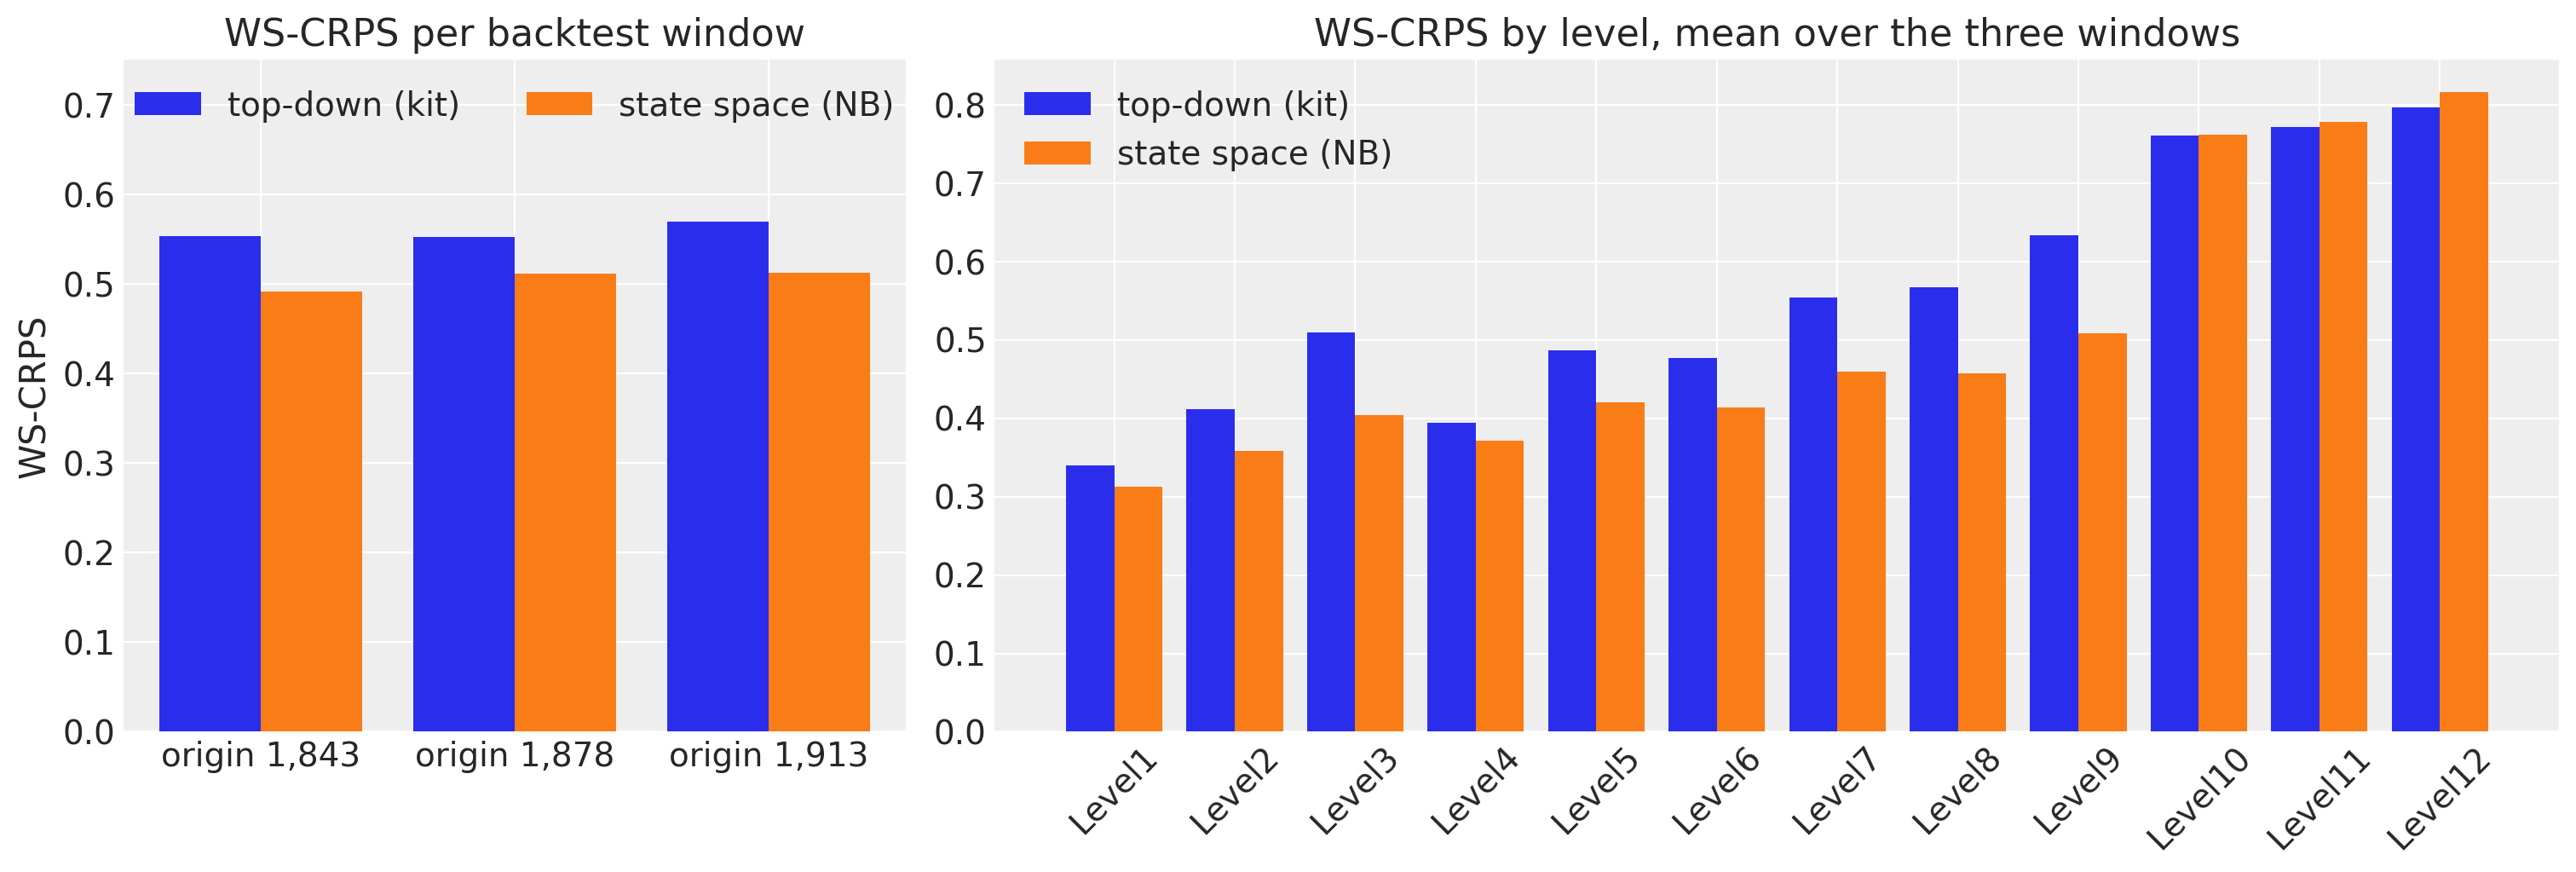

In [10]:
backtest_mean = (
    backtest_df.group_by("model", maintain_order=True)
    .agg(pl.col("ws_crps", "ws_crps_1_9", "ws_crps_10_12", *LEVEL_COLUMNS).mean())
    .sort("model", descending=True)
)
fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(15, 5), width_ratios=[1, 2], layout="constrained"
)
width = 0.4
x = np.arange(len(BACKTEST_ORIGINS))
for k, name in enumerate(backtest_mean["model"]):
    rows = backtest_df.filter(pl.col("model").eq(pl.lit(name))).sort("t1")
    axes[0].bar(x + (k - 0.5) * width, rows["ws_crps"].to_numpy(), width, label=name)
axes[0].set_xticks(x, [f"origin {origin:,}" for origin in BACKTEST_ORIGINS])
axes[0].set(title="WS-CRPS per backtest window", ylabel="WS-CRPS", ylim=(0.0, 0.75))
axes[0].legend(loc="upper center", ncols=2)
x = np.arange(len(LEVELS))
for k, name in enumerate(backtest_mean["model"]):
    row = backtest_mean.filter(pl.col("model").eq(pl.lit(name)))
    axes[1].bar(
        x + (k - 0.5) * width,
        row.select(LEVEL_COLUMNS).to_numpy()[0],
        width,
        label=name,
    )
axes[1].set_xticks(x, list(LEVELS), rotation=45)
axes[1].set(title="WS-CRPS by level, mean over the three windows")
axes[1].legend();

## The final fit

The model is now fitted once on the last two years before the evaluation
window. The loss rises during the warm-up of the one-cycle schedule (the
peak learning rate is reached at step 600) and then falls for the rest
of the run; it is still going down slowly at step 3,000, so a longer run
would buy a little more, at a cost that the timing section puts in
context.

final model: 3000 steps in 112 s, final loss 2.559e+07

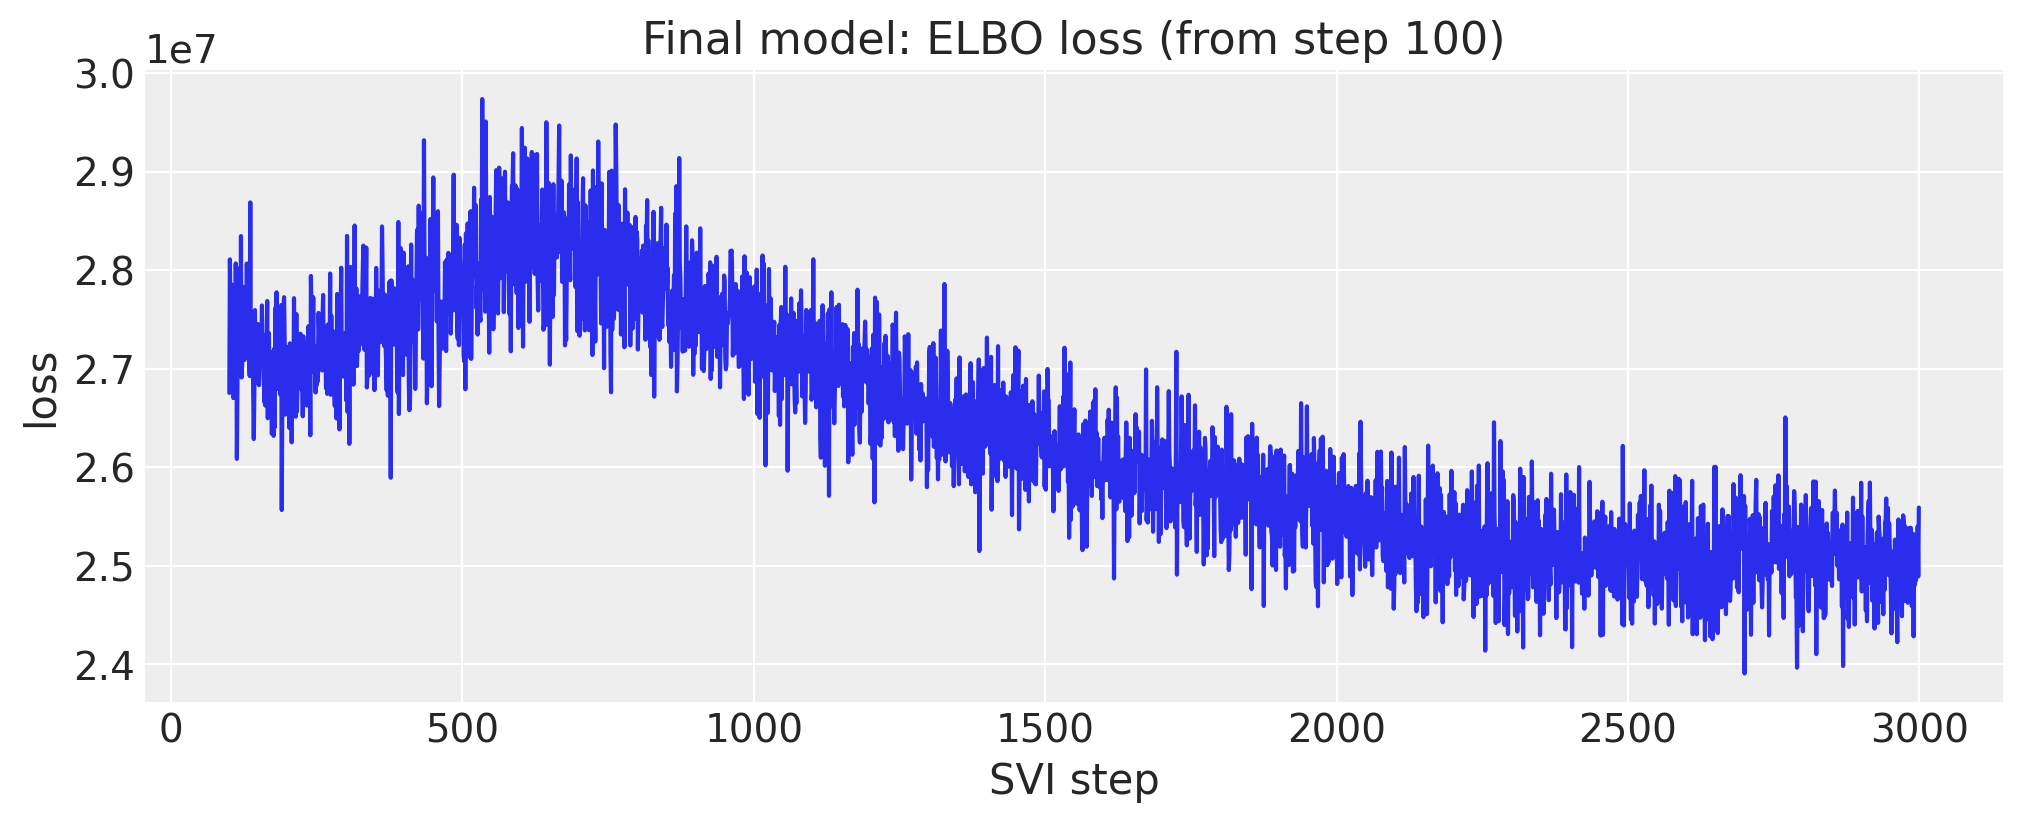

In [11]:
rng_key, key_fit = random.split(rng_key)
guide_final, svi_final, time_final = fit_model(
    key_fit, final_model, covariates_final[:, :HISTORY_DAYS], counts_final
)
print(
    f"final model: {NUM_STEPS} steps in {time_final:.0f} s, final loss {float(svi_final.losses[-1]):.4g}"
)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(100, NUM_STEPS), np.asarray(svi_final.losses[100:]), color="C0")
ax.set(title="Final model: ELBO loss (from step 100)", xlabel="SVI step", ylabel="loss");

### Posterior of the shared parameters

The population scales tell how much each component moves. The intercept
deviations $\sigma^{\alpha}$ are 0.10 to 0.23 on the log scale by
department (the prior center, the last-28-day level, is close for most
items), the item dispersion spreads $\tau$ are 0.58 to 0.84 (large:
item-level dispersion matters), the block-walk innovation scales are
0.13 to 0.22 per 28-day block (larger for the FOODS departments than for
HOBBIES and HOUSEHOLD), the item weekday deviations are 0.03 to 0.08,
and the store shock scales are 0.06 to 0.11, highest for the Wisconsin
stores and TX_2. The posterior standard deviations are tiny: with 30,490
series behind each population parameter and a mean-field guide, these
are effectively point estimates.

The weekday effects of the departments of store CA_1 show the weekend
peak of every department (Saturday and Sunday $+0.1$ to $+0.3$ on the
log scale, Tuesday to Thursday $-0.05$ to $-0.2$), with the shape
varying by department. The SNAP effect is strongest for the FOODS
departments of the Wisconsin and Texas stores (up to $+0.6$ for
WI_2/FOODS_2, that is $\times 1.8$ on SNAP days) and close to zero for
HOBBIES and HOUSEHOLD, as expected of a food-stamp program. The calendar
events read as expected too: Thanksgiving is $-0.4$ for FOODS_3 and
$-0.85$ for HOBBIES_1 (the stores close early), Mother’s Day and New
Year are negative, Labor Day, Presidents’ Day and Columbus Day are
positive for FOODS_3. Christmas is the one event with a wide posterior:
the stores are closed, `saled` is zero and the effect only sees its
prior.

In [12]:
rng_key, key_post = random.split(rng_key)
posterior_final = draw_posterior(key_post, guide_final, svi_final.params, 500)
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
SHARED_DIMS = {
    "sigma_alpha": ["dept"],
    "tau_phi": ["dept"],
    "sigma_walk": ["dept"],
    "sigma_item_dow": ["dept"],
    "sigma_event": ["dept"],
    "w_fourier": ["dept", "harmonic"],
    "gamma_event": ["dept", "event"],
    "store_shock_scale": ["store"],
    "log_phi_group": ["group"],
    "seasonal_group": ["group", "day_of_week"],
    "snap_group": ["group"],
}
tree_final = az.from_dict(
    {"posterior": {name: np.asarray(posterior_final[name])[None] for name in SHARED_DIMS}},
    coords={
        "dept": dept_ids,
        "group": group_ids,
        "store": store_ids,
        "day_of_week": DOW_LABELS,
        "event": ["none", *event_names],
        "harmonic": [f"{f}{k}" for f in ("sin", "cos") for k in range(1, N_HARMONICS + 1)],
    },
    dims=SHARED_DIMS,
)
az.summary(
    tree_final,
    var_names=["sigma_alpha", "tau_phi", "sigma_walk", "sigma_item_dow", "store_shock_scale"],
)

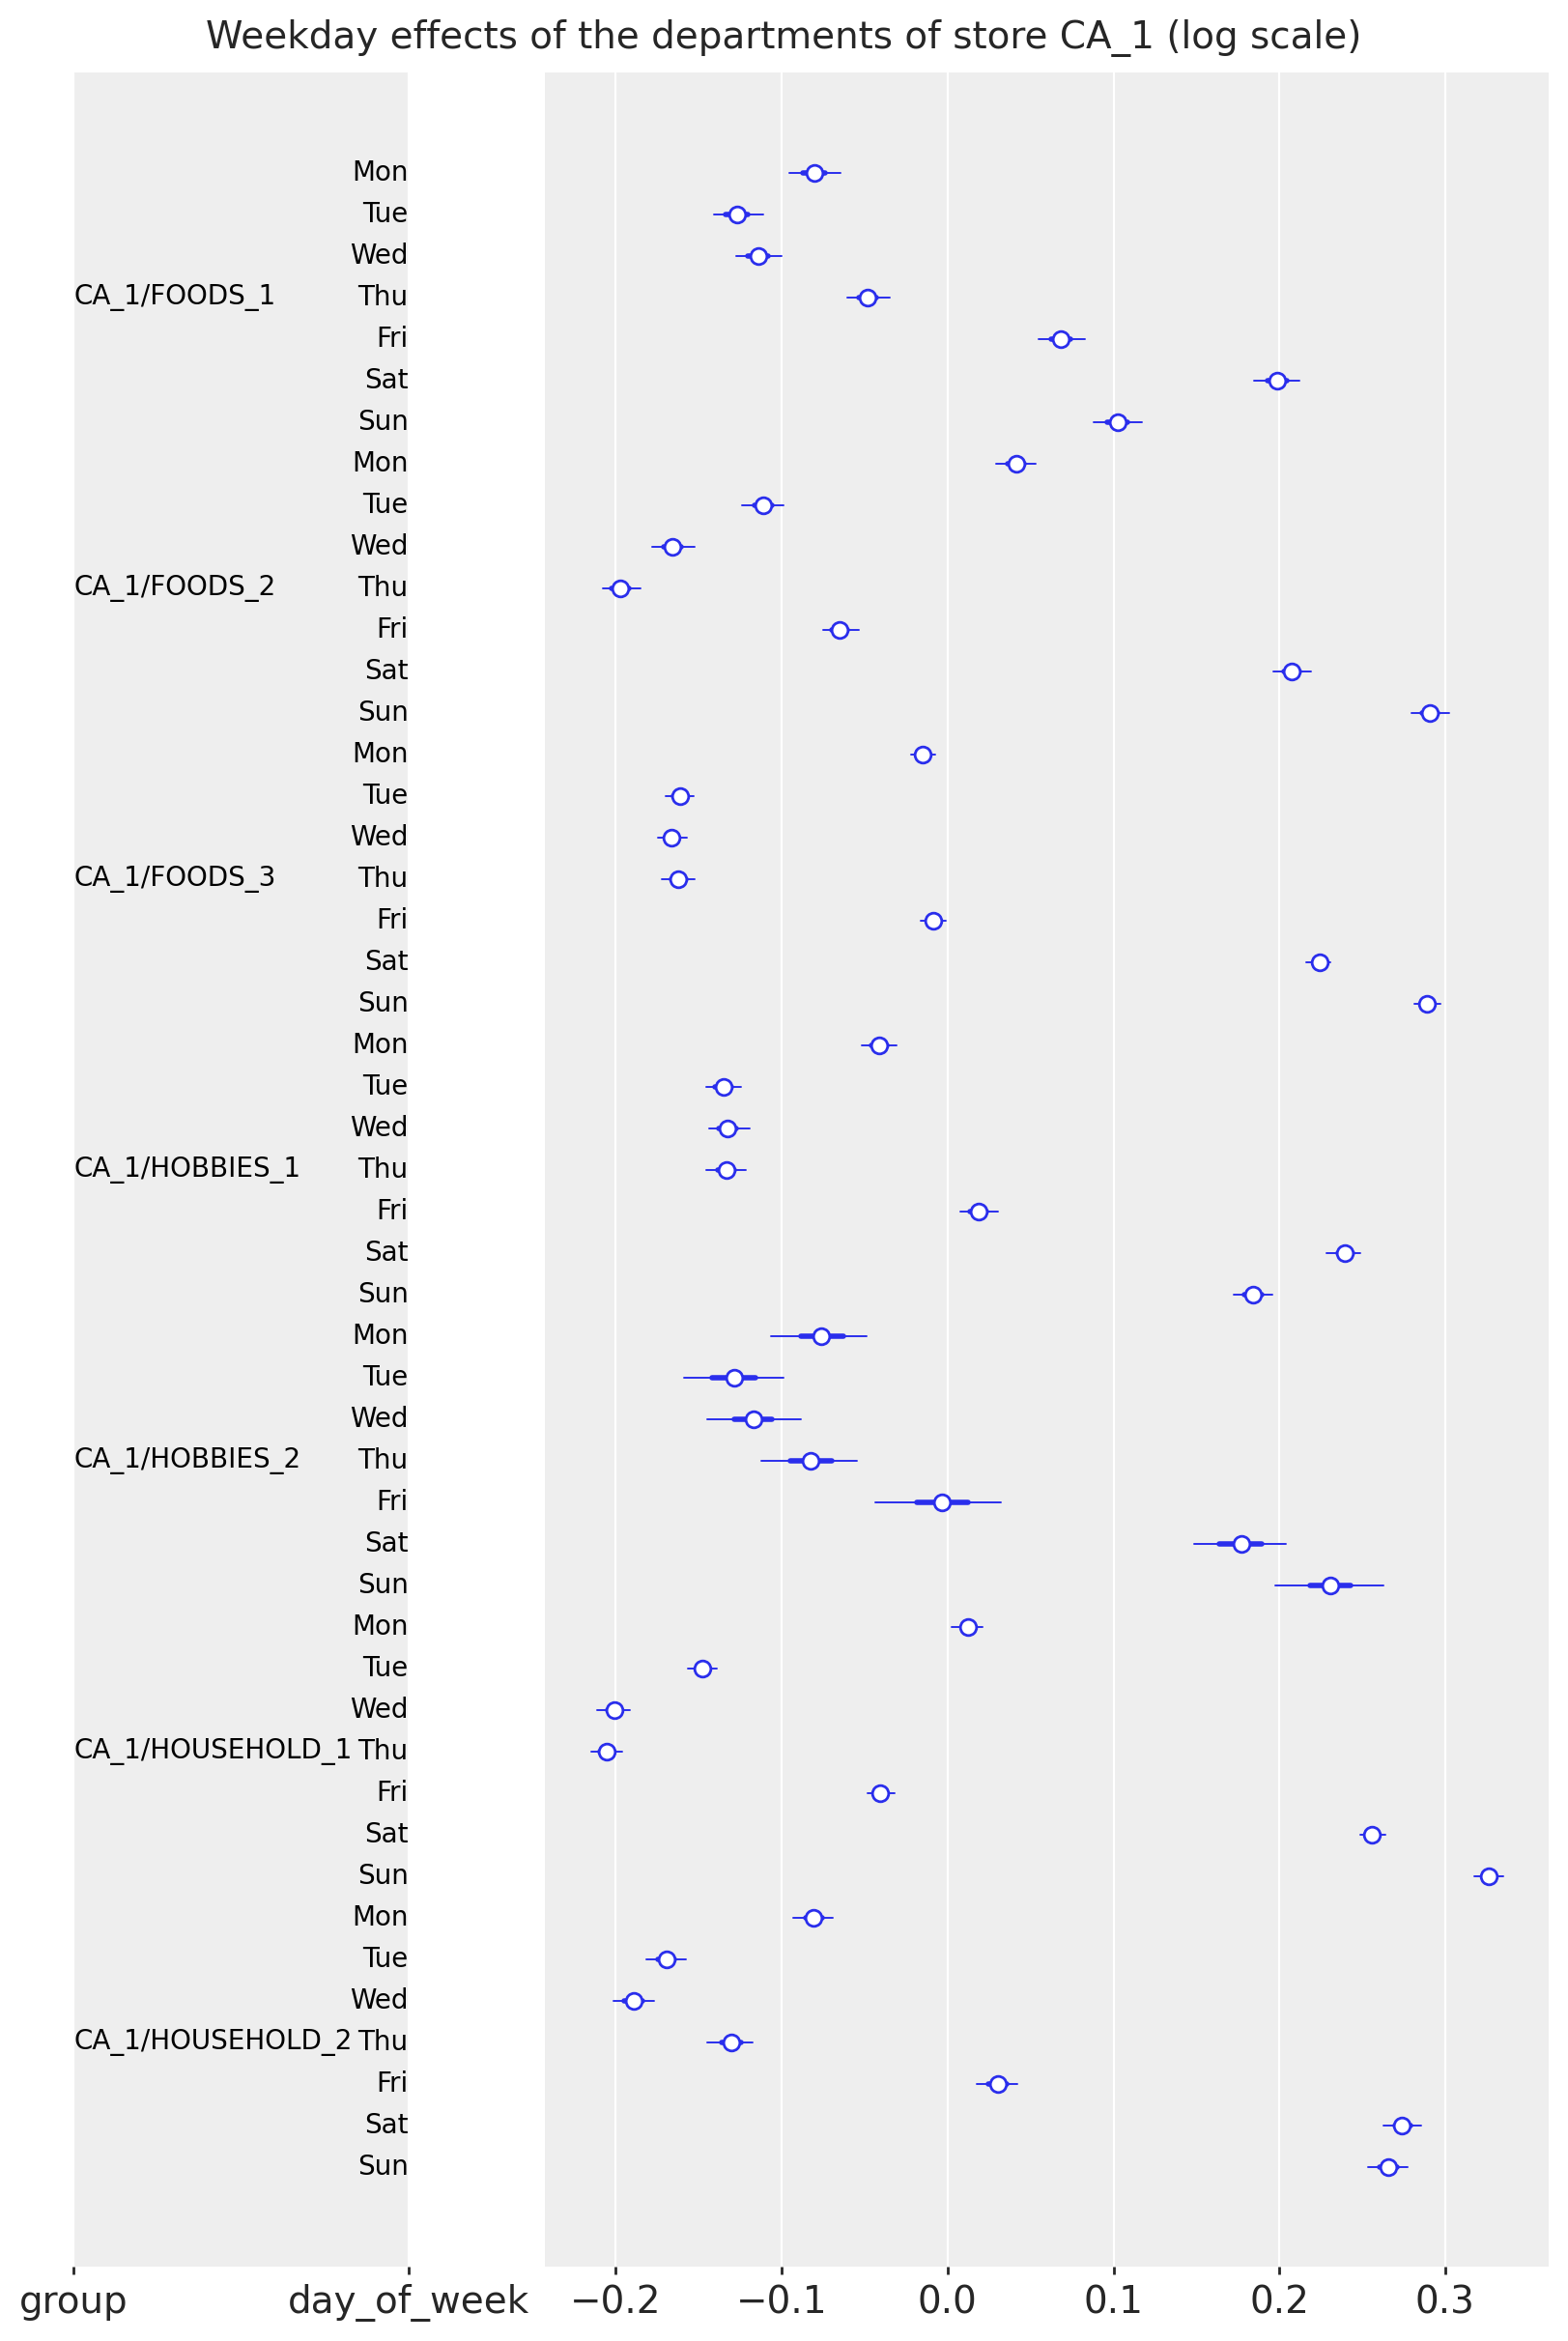

In [13]:
ca1_groups = [label for label in group_ids if label.startswith("CA_1/")]
pc = az.plot_forest(
    tree_final,
    var_names=["seasonal_group"],
    coords={"group": ca1_groups},
    combined=True,
    labels=["group", "day_of_week"],
    figure_kwargs={"figsize": (8, 12)},
)
pc.viz["figure"].item().suptitle(
    "Weekday effects of the departments of store CA_1 (log scale)", fontsize=14
);

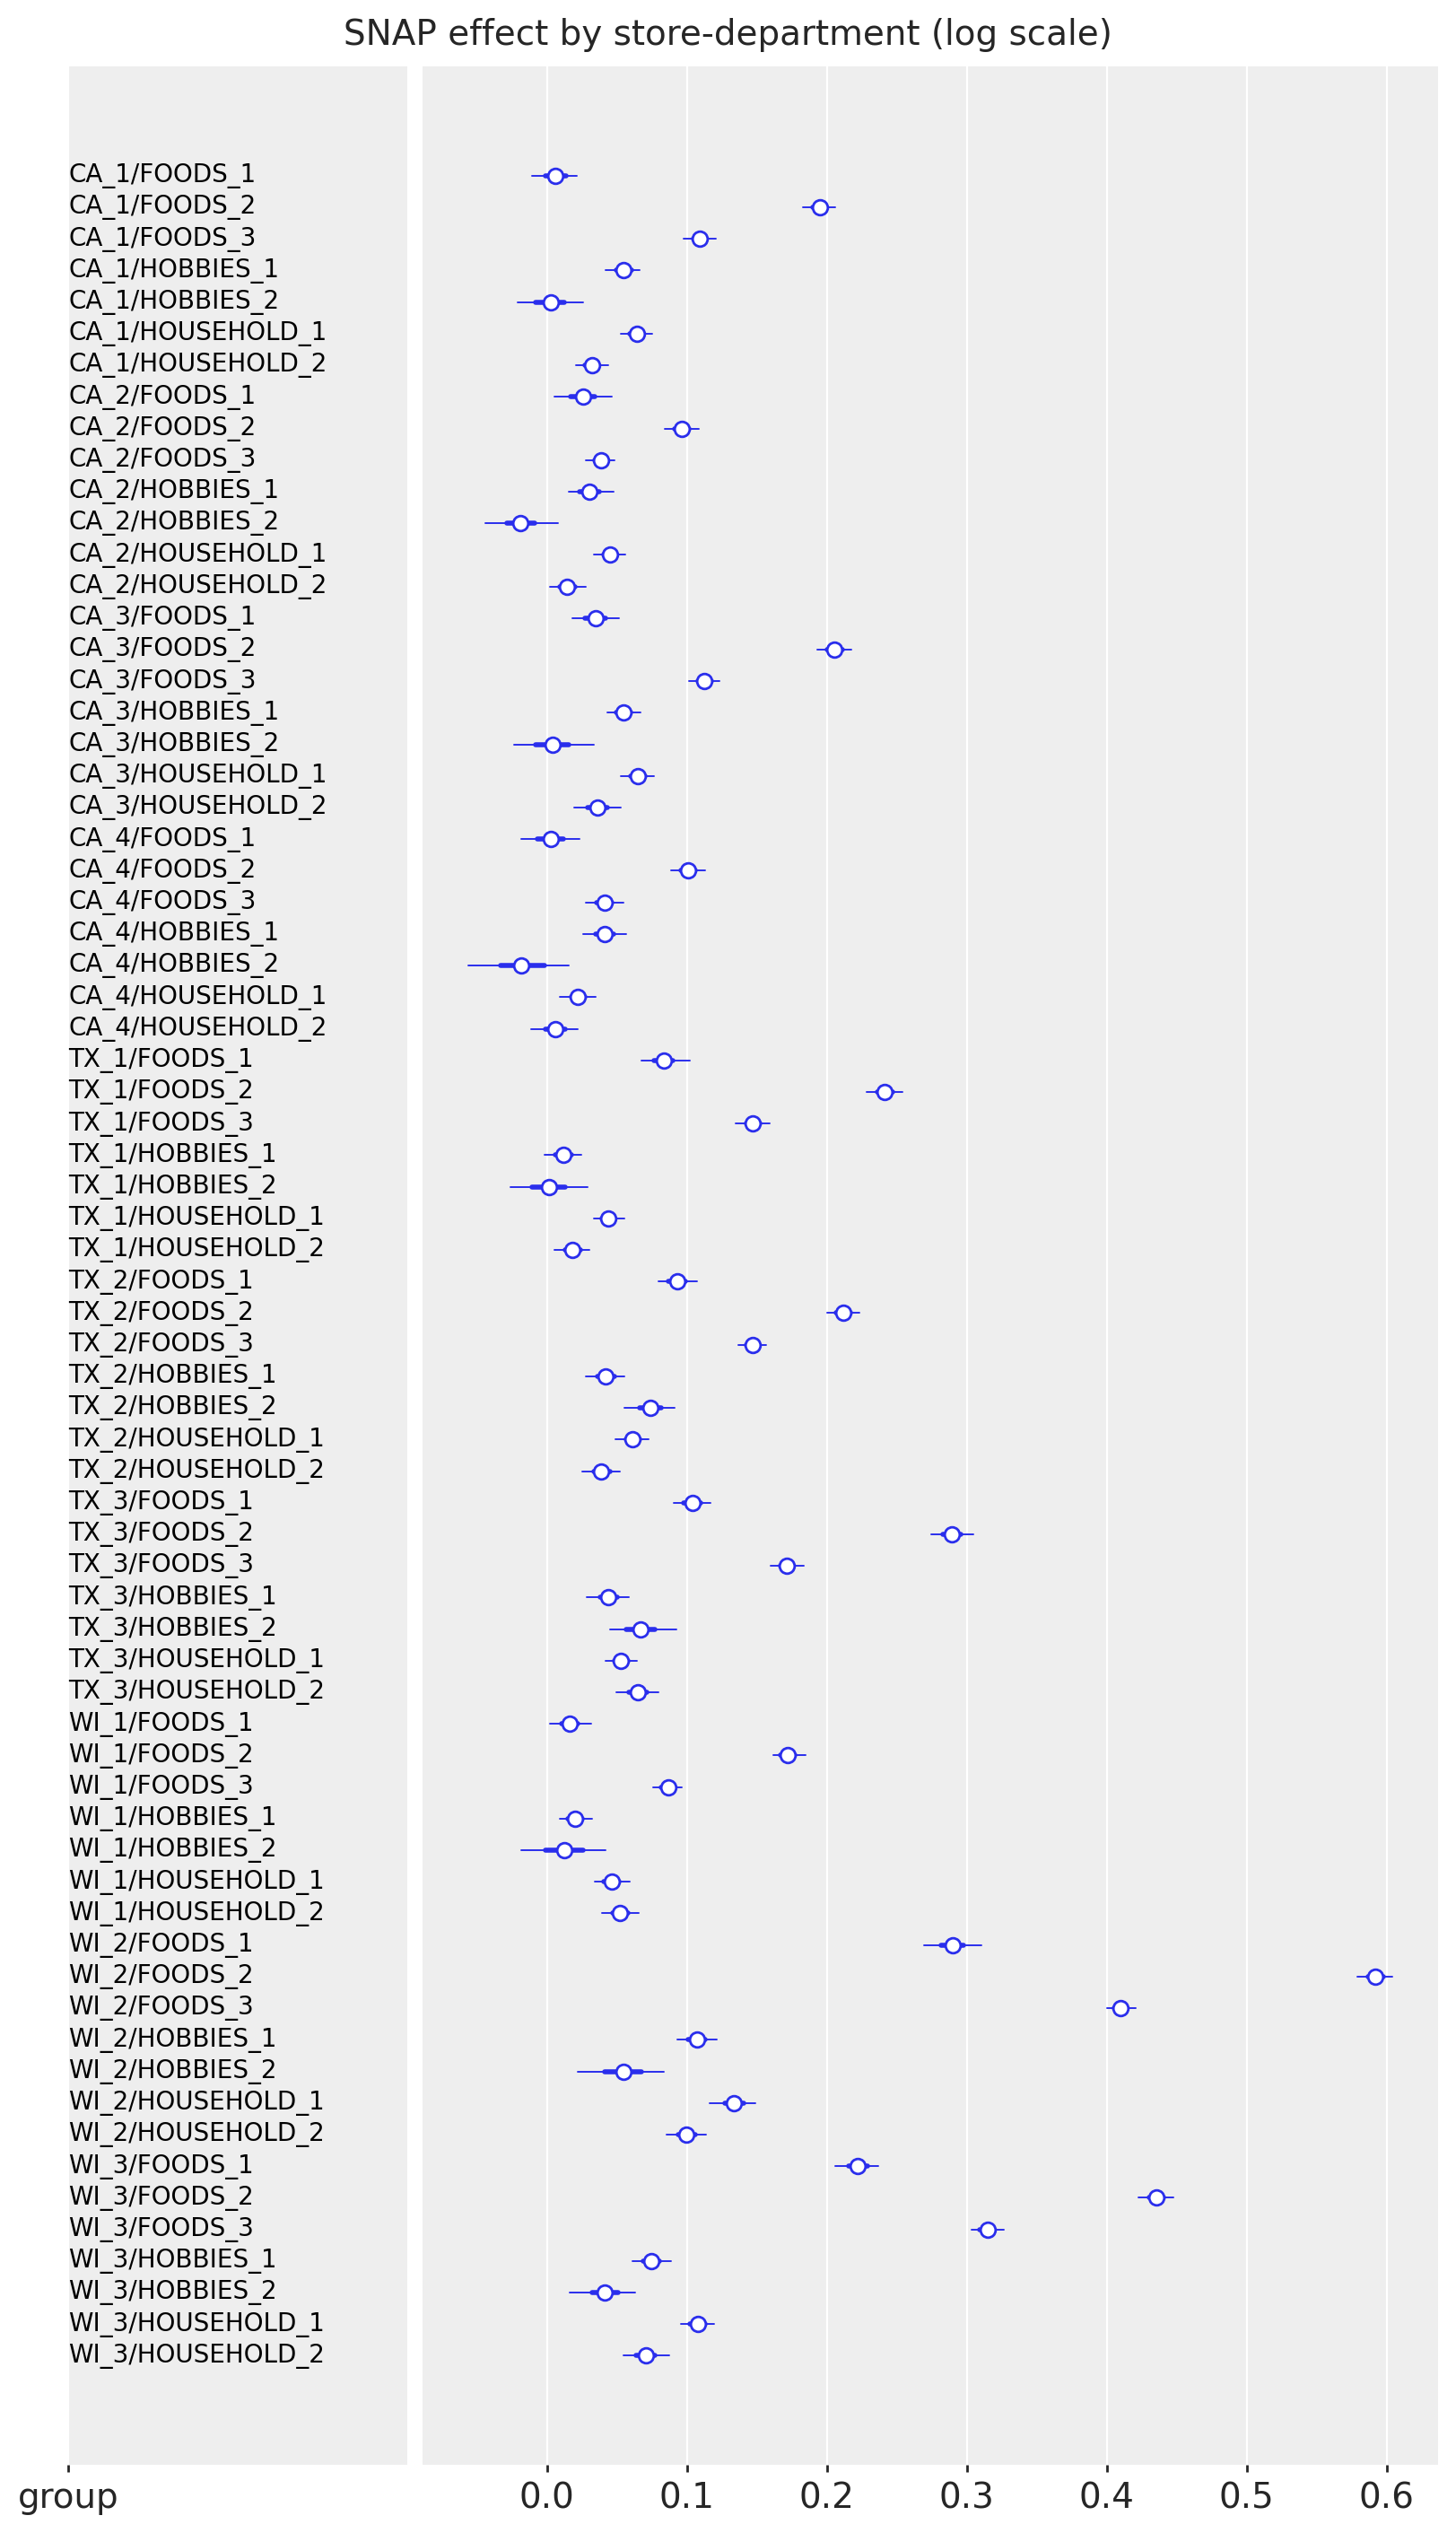

In [14]:
pc = az.plot_forest(
    tree_final,
    var_names=["snap_group"],
    combined=True,
    labels=["group"],
    figure_kwargs={"figsize": (8, 14)},
)
pc.viz["figure"].item().suptitle("SNAP effect by store-department (log scale)", fontsize=14);

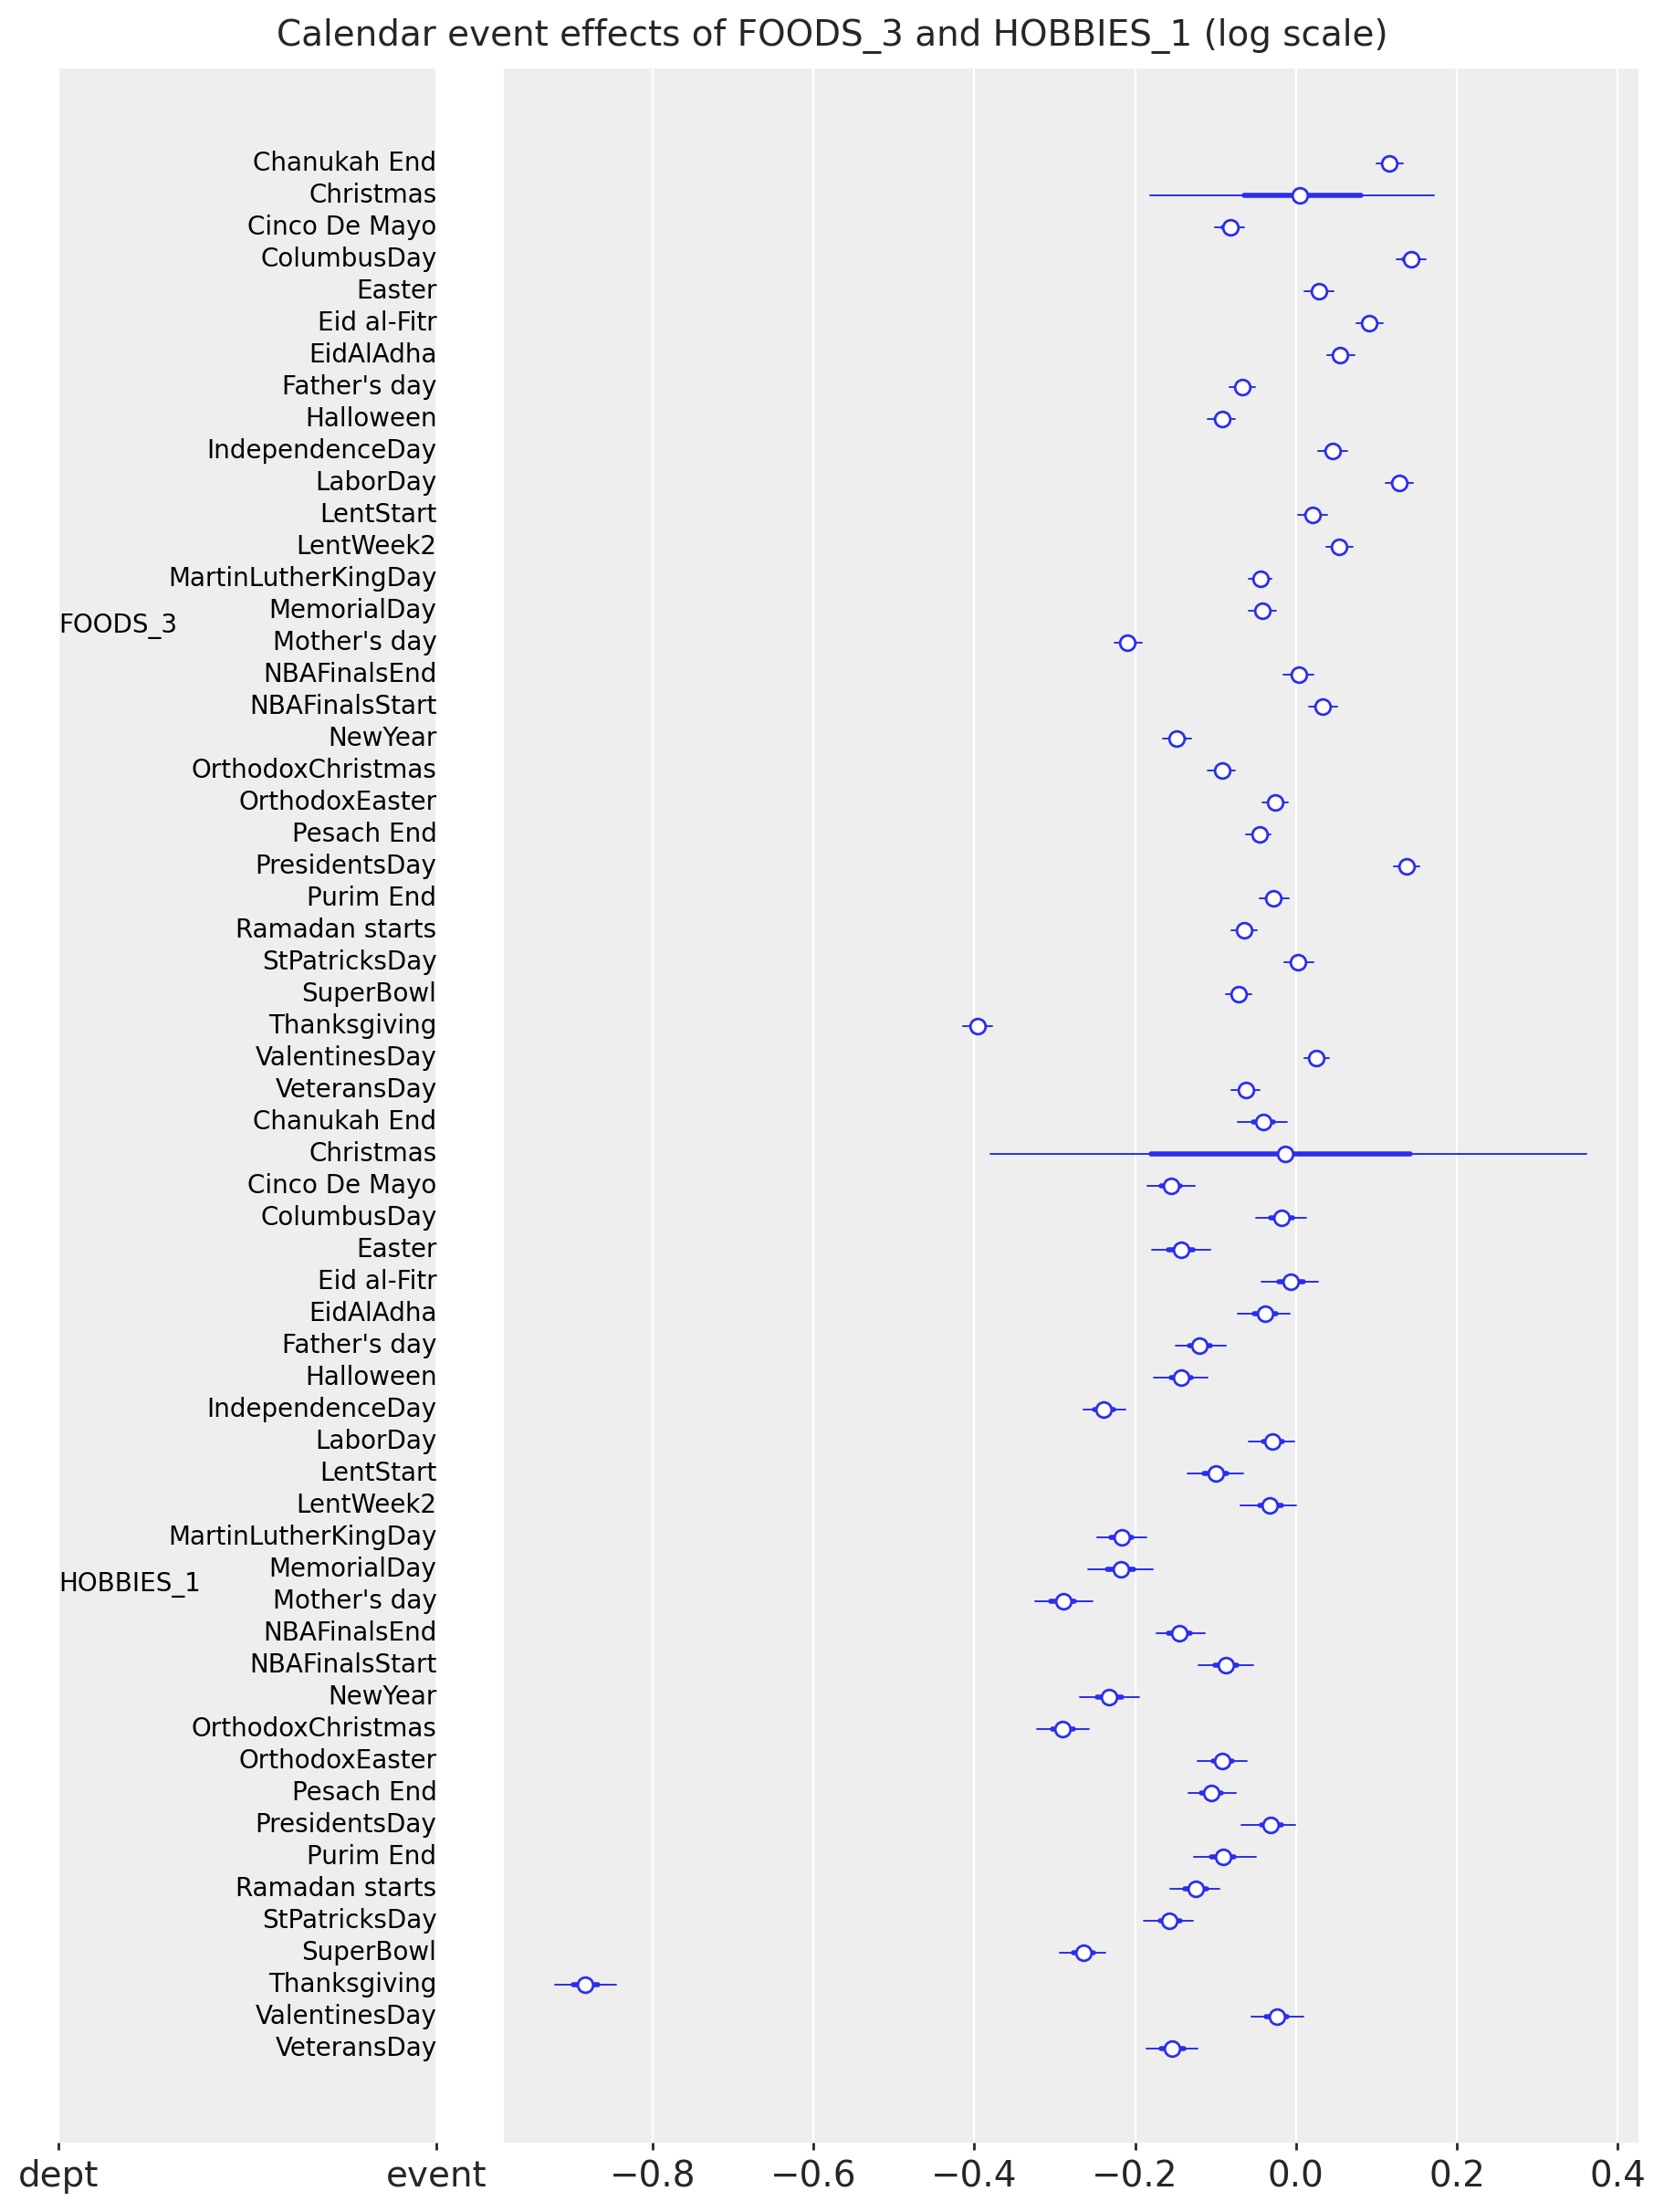

In [15]:
pc = az.plot_forest(
    tree_final,
    var_names=["gamma_event"],
    coords={"dept": ["FOODS_3", "HOBBIES_1"], "event": event_names},
    combined=True,
    labels=["dept", "event"],
    figure_kwargs={"figsize": (9, 12)},
)
pc.viz["figure"].item().suptitle(
    "Calendar event effects of FOODS_3 and HOBBIES_1 (log scale)", fontsize=14
);

### Focus items

Seven items of store CA_1, the best seller of each department over the
last training year. The prior predictive check of the last 16 training
weeks shows what the priors allow before seeing the data: bands that
reach 10 to 20 times the observed level, wide but not absurd for a count
model whose intercept is centered on the recent level. The in-sample
predictive and the forecast come from `predict_in_sample()` and
`forecast()` on a seven-series instance of the model that reads the
item-level draws of these series; the wide upper tails of FOODS_3_090
are the negative binomial dispersion of a bursty series, and
HOUSEHOLD_1_334 shows the block walk at work: its level dropped in May
and the forecast follows the last block, not the two-year mean.

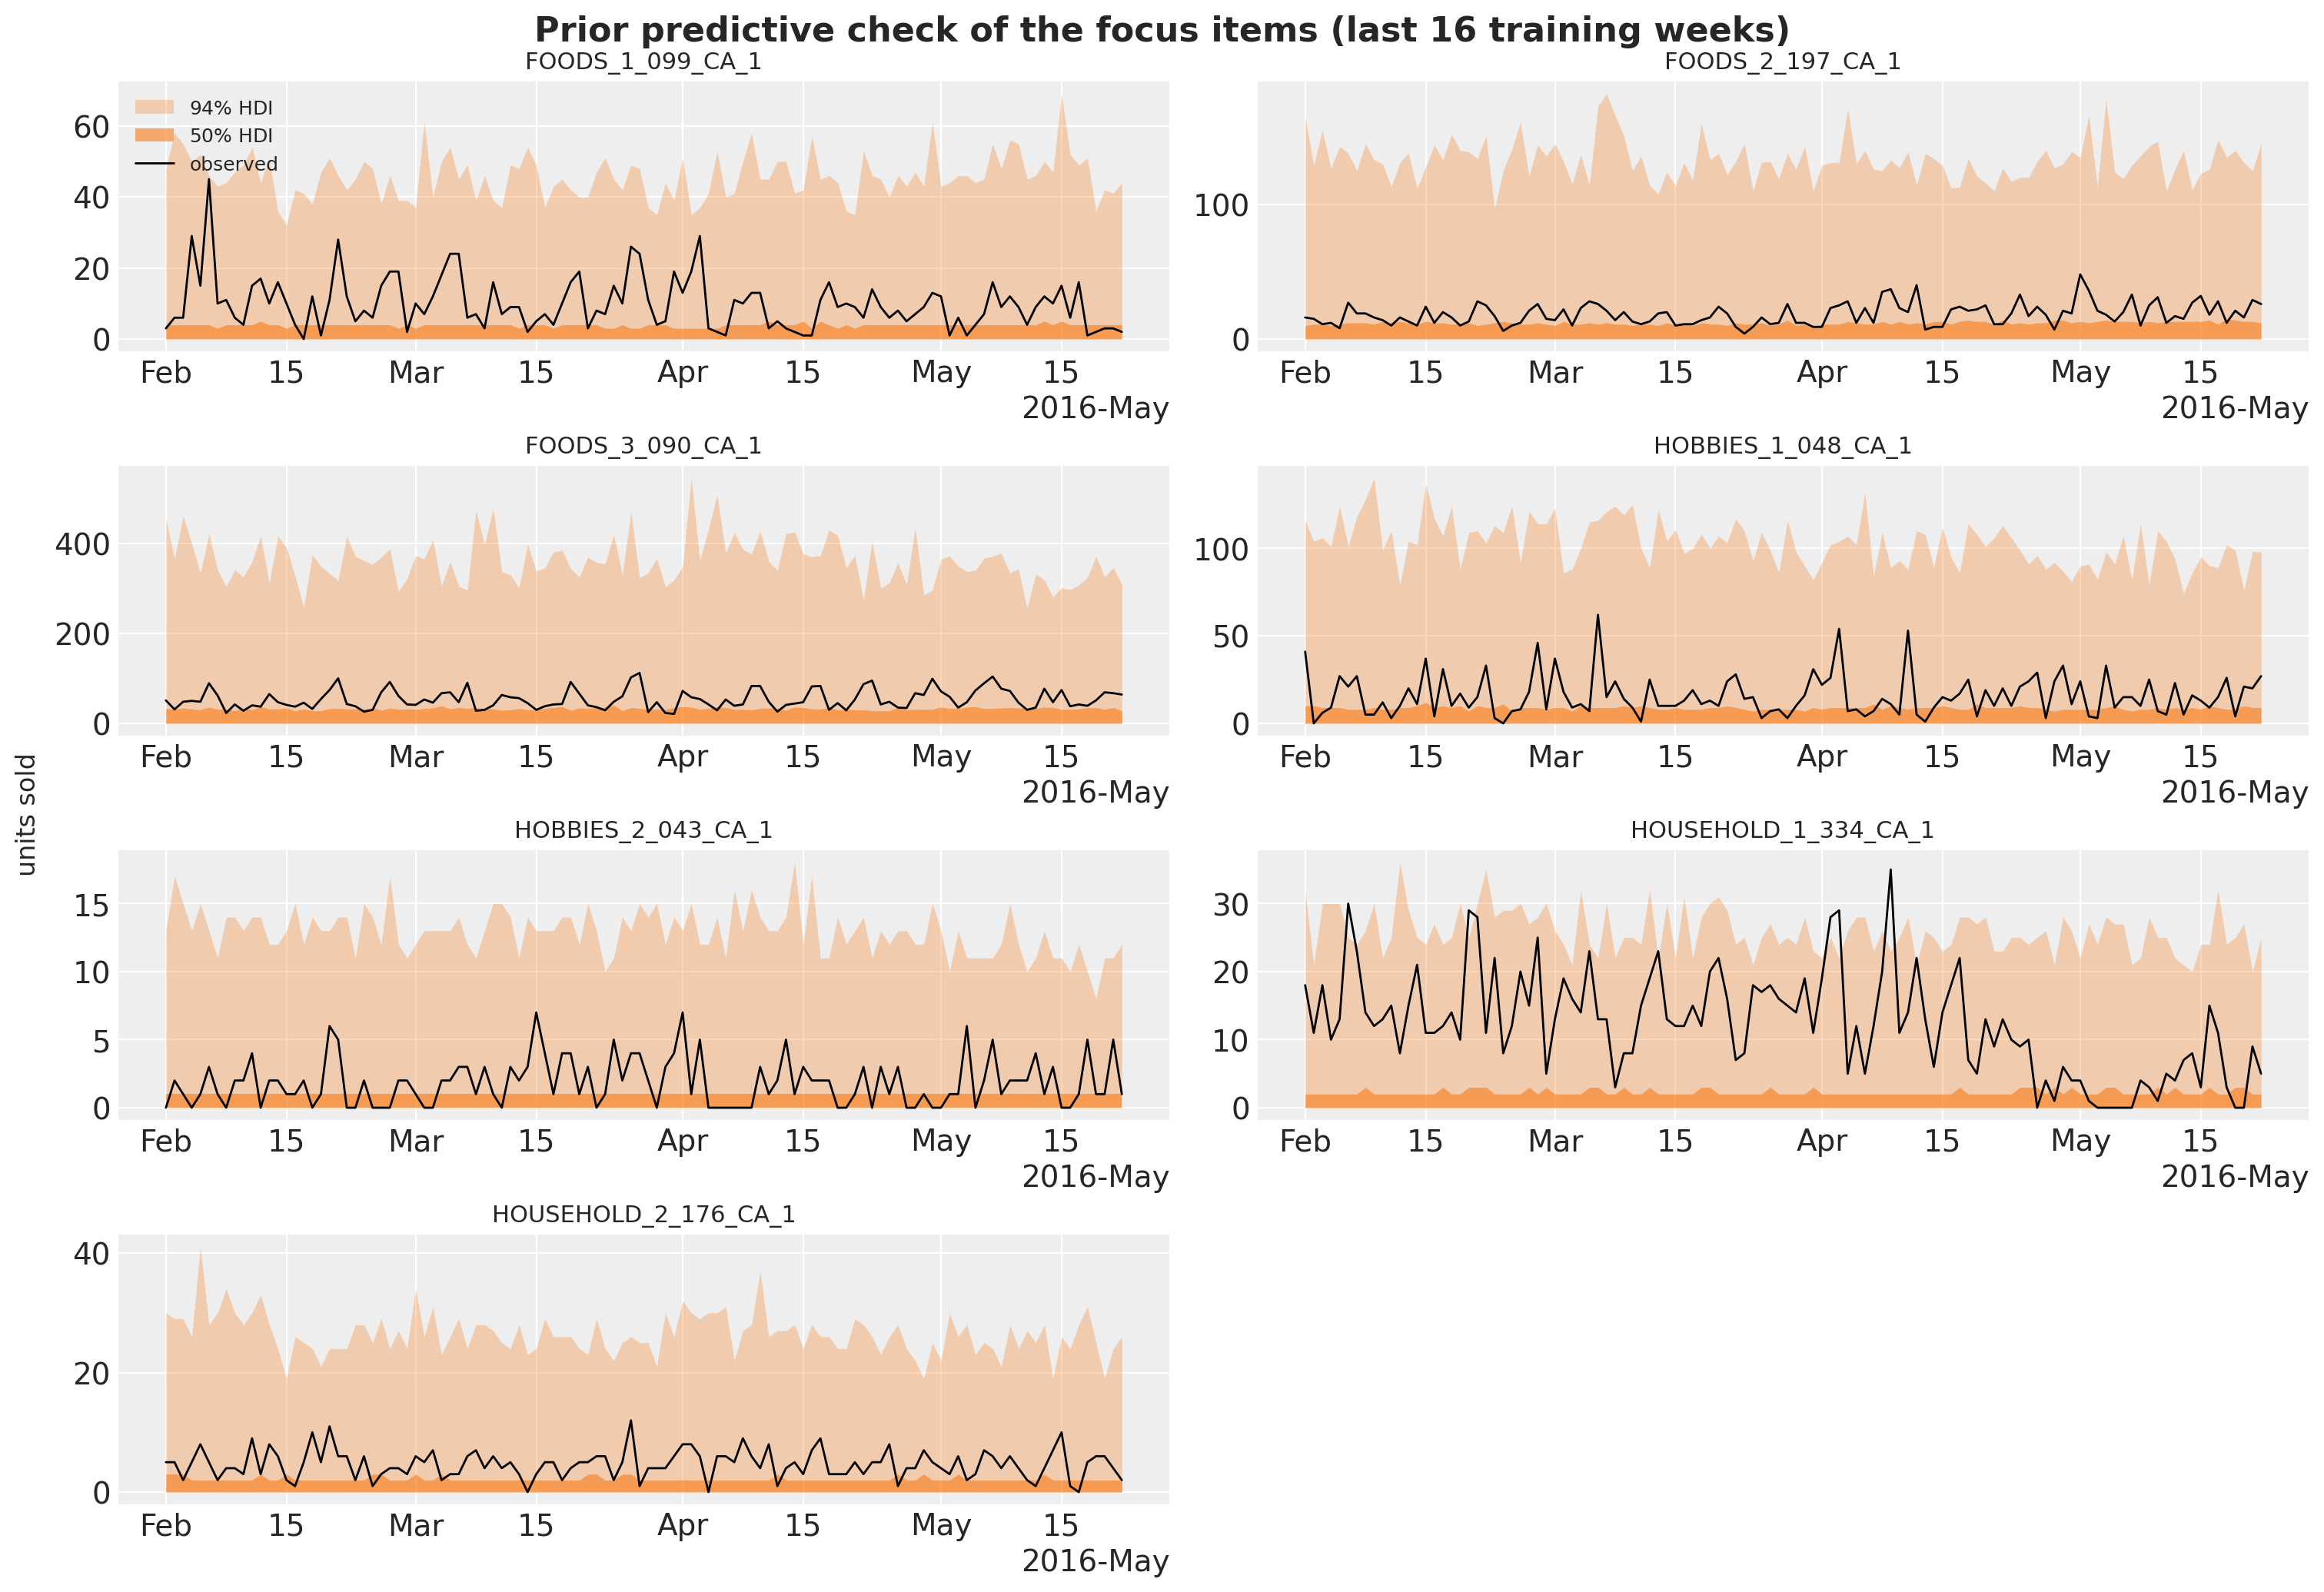

In [16]:
HDI_PROBS = (0.94, 0.5)
HDI_ALPHAS = (0.3, 0.6)
dates = calendar_df["date"].to_numpy()[:N_DAYS]
date_num = np.asarray(mdates.date2num(dates.astype("datetime64[s]").astype(object)))
split_date = date_num[N_DAYS_TRAIN]
plot_start = N_DAYS_TRAIN - 16 * 7
last_year_sales = sales[N_DAYS_TRAIN - 365 : N_DAYS_TRAIN].sum(0)
focus_df = (
    hierarchy_df.with_row_index("n")
    .with_columns(last_year=pl.Series(last_year_sales))
    .filter(pl.col("store_id").eq(pl.lit("CA_1")))
    .sort("last_year", descending=True)
    .group_by("dept_id", maintain_order=True)
    .head(1)
    .sort("dept_id")
)
focus_index = focus_df["n"].to_numpy()
focus_labels = focus_df["id"].to_list()
ITEM_SITES = {"alpha": -1, "log_phi": -1, "item_walk": -1, "item_dow": -2}


def subset_posterior(posterior: dict, index: np.ndarray) -> dict:
    """Keep the draws of the series in ``index`` for the item-level sites, everything else as is."""
    out = {}
    for name, value in posterior.items():
        if name in ITEM_SITES:
            axis = ITEM_SITES[name] % value.ndim
            out[name] = jnp.take(value, jnp.asarray(index), axis=axis)
        else:
            out[name] = value
    return out


def hdi_label(prob: float) -> str:
    r"""Legend label of an HDI band, for example ``$94\%$ HDI``."""
    return rf"${prob:.0%}$ HDI".replace("%", r"\%")


def plot_series_panel(
    train_draws: np.ndarray | Array | None,
    test_draws: np.ndarray | Array,
    truth: np.ndarray,
    labels: list[str],
    x_train: np.ndarray,
    x_test: np.ndarray,
    *,
    ylabel: str,
    suptitle: str,
    col_wrap: int = 2,
    figsize: tuple[float, float] = (15.0, 10.0),
    group: str = "posterior_predictive",
) -> None:
    """Facet the predictive bands of a few series over a window, with the observed series."""
    visuals = {
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    }
    first_draws, first_x = (test_draws, x_test) if train_draws is None else (train_draws, x_train)
    pc = az.plot_lm(
        predictions_to_datatree(
            np.asarray(first_draws, dtype=np.float32), first_x, labels, group=group
        ),
        y="obs",
        x="t",
        plot_dim="time",
        group=group,
        ci_kind="hdi",
        ci_prob=HDI_PROBS,
        smooth=False,
        col_wrap=col_wrap,
        visuals=visuals if train_draws is not None else {**visuals, "ci_band": {"color": "C1"}},
        aes={"alpha": ["prob"]},
        alpha=HDI_ALPHAS,
        figure_kwargs={"figsize": figsize},
    )
    if train_draws is not None:
        az.plot_lm(
            predictions_to_datatree(
                np.asarray(test_draws, dtype=np.float32), x_test, labels, group=group
            ),
            y="obs",
            x="t",
            plot_dim="time",
            group=group,
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=HDI_PROBS,
            smooth=False,
            visuals={**visuals, "ci_band": {"color": "C1"}},
        )
    x_all = np.concatenate([x_train, x_test]) if train_draws is not None else x_test
    truth_da = xr.DataArray(
        np.asarray(truth)[-len(x_all) :],
        dims=["time", "series"],
        coords={"time": x_all, "series": labels},
    ).rename("t")
    x_da = xr.DataArray(x_all, dims=["time"], coords={"time": x_all})
    pc.map(
        az.visuals.line_xy,
        "truth",
        data=truth_da,
        x=x_da,
        ignore_aes=pc.aes_set,
        color="black",
        lw=1,
    )
    for label in labels:
        ax = pc.get_target("t", {"series": label})
        ax.set_title(label, fontsize=11)
        locator = mdates.AutoDateLocator()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax0 = pc.get_target("t", {"series": labels[0]})
    handles = []
    for prob in HDI_PROBS:
        band = pc.viz["ci_band"]["t"].sel(series=labels[0], prob=prob).item()
        band.set_label(hdi_label(prob))
        handles.append(band)
    truth_line = pc.viz["truth"]["t"].sel(series=labels[0]).item()
    truth_line.set_label("observed")
    ax0.legend(handles=[*handles, truth_line], loc="upper left", fontsize=9)
    fig = pc.viz["figure"].item()
    fig.supylabel(ylabel)
    fig.suptitle(suptitle, fontsize=16, fontweight="bold", y=1.02)


focus_model = make_model(
    level_final[focus_index],
    store_index=store_index[focus_index],
    group_index=group_index[focus_index],
    dept_index=dept_index[focus_index],
)
posterior_focus = subset_posterior(posterior_final, focus_index)
covariates_focus = covariates_final[:, :, focus_index]
rng_key, key_prior, key_fc = random.split(rng_key, 3)
prior_focus = Predictive(focus_model, num_samples=500, return_sites=["obs"])(
    key_prior, covariates_focus[:, :HISTORY_DAYS]
)["obs"]
fc_focus = forecast(
    key_fc, focus_model, posterior_focus, counts_final[:, focus_index], covariates_focus
)
plot_series_panel(
    None,
    prior_focus[:, -16 * 7 :],
    sales[plot_start:N_DAYS_TRAIN, focus_index],
    focus_labels,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[plot_start:N_DAYS_TRAIN],
    ylabel="units sold",
    suptitle="Prior predictive check of the focus items (last 16 training weeks)",
    group="prior_predictive",
)

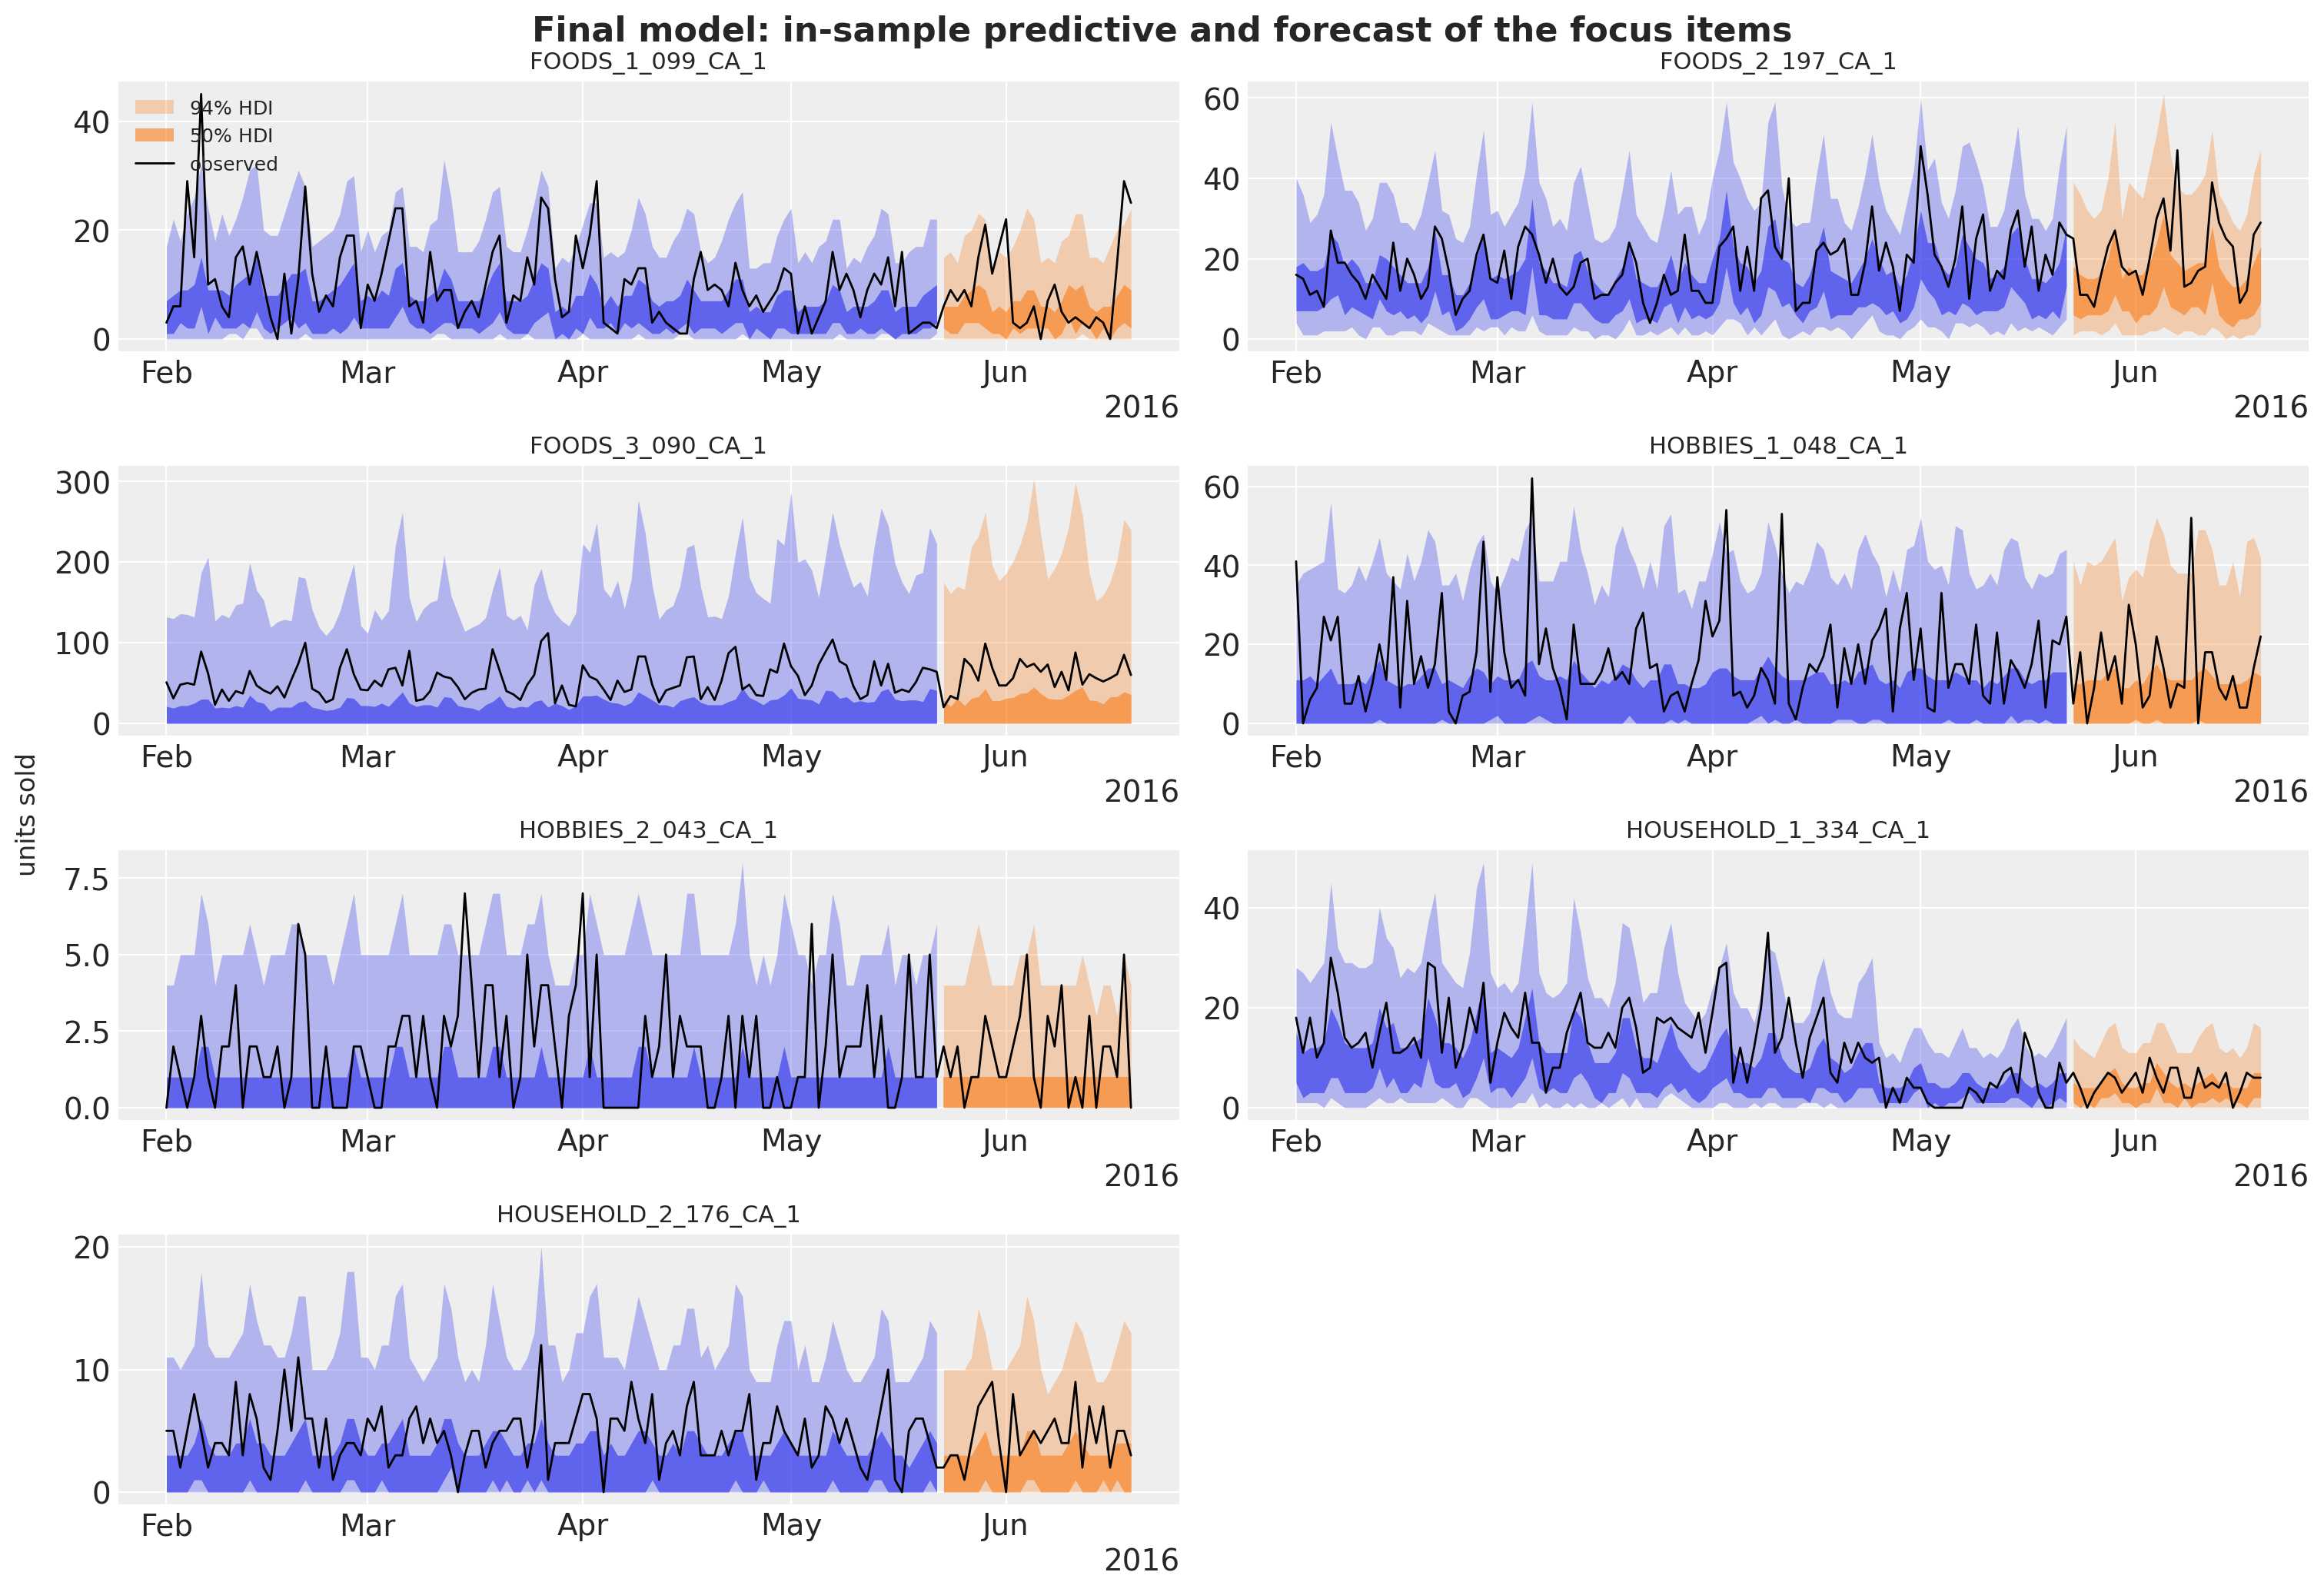

In [17]:
rng_key, key_pp = random.split(rng_key)
pp_focus = predict_in_sample(
    key_pp, focus_model, posterior_focus, covariates_focus[:, :HISTORY_DAYS]
)
plot_series_panel(
    np.asarray(pp_focus)[:, -16 * 7 :],
    fc_focus,
    sales[plot_start:N_DAYS, focus_index],
    focus_labels,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[N_DAYS_TRAIN:N_DAYS],
    ylabel="units sold",
    suptitle="Final model: in-sample predictive and forecast of the focus items",
)
del prior_focus, pp_focus

## The evaluation window

The final model forecasts the 28 evaluation days (`d_1942` to `d_1969`)
with 500 draws and is scored against the top-down baseline, re-run here
with 500 draws as well. The middle-out and bottom-up baselines scored
0.634 and 0.728 on this window in the baselines notebook.

In [18]:
rng_key, key_fc = random.split(rng_key)
start = perf_counter()
bottom_final = forecast_bottom_level(
    key_fc, guide_final, svi_final.params, counts_final, covariates_final, 500
)
time_fc_final = perf_counter() - start
print(f"bottom-level forecast {bottom_final.shape} in {time_fc_final:.0f} s")
truth_holdout = sales[N_DAYS_TRAIN:N_DAYS]
holdout_metrics = m5_metrics(0, N_DAYS_TRAIN, N_DAYS)
weights_holdout = m5_weights(N_DAYS_TRAIN)
scales_holdout = m5_scales(sales_agg[:N_DAYS_TRAIN])
pred_levels, truth_levels = aggregate_transform(bottom_final, truth_holdout)
scores_final = evaluate_forecast(pred_levels, truth_levels, metrics=holdout_metrics)
wspl_final = ws_pinball(pred_levels, truth_levels, weights_holdout, scales_holdout)
level1_final = pred_levels[..., 0]
level3_final = pred_levels[..., level_slices["Level3"]]
del bottom_final, pred_levels

rng_key, key_top = random.split(rng_key)
start = perf_counter()
bottom_top = forecast_fn_top_down(
    key_top, top_down_model, sales_train, covariates_top[:N_DAYS_TRAIN], covariates_top, 500
)
time_top_fc = perf_counter() - start
pred_levels, _ = aggregate_transform(bottom_top, truth_holdout)
scores_top = evaluate_forecast(pred_levels, truth_levels, metrics=holdout_metrics)
wspl_top = ws_pinball(pred_levels, truth_levels, weights_holdout, scales_holdout)
level1_top = pred_levels[..., 0]
del bottom_top, pred_levels


def ws_crps_mean(scores: dict) -> float:
    """Mean of the 12 level scores of an ``evaluate_forecast`` result."""
    return float(np.mean([scores[f"ws_crps_{level}"] for level in LEVELS]))


holdout_table = pl.DataFrame(
    {
        "metric": [*LEVELS, "mean", "WSPL", *[f"coverage {level}" for level in COVERAGE_LEVELS]],
        "top-down (kit)": [
            *[scores_top[f"ws_crps_{level}"] for level in LEVELS],
            ws_crps_mean(scores_top),
            wspl_top,
            *[scores_top[f"coverage_{level}"] for level in COVERAGE_LEVELS],
        ],
        "state space (NB)": [
            *[scores_final[f"ws_crps_{level}"] for level in LEVELS],
            ws_crps_mean(scores_final),
            wspl_final,
            *[scores_final[f"coverage_{level}"] for level in COVERAGE_LEVELS],
        ],
    }
).with_columns(pl.col(pl.Float64).round(3))
holdout_table

bottom-level forecast (500, 28, 30490) in 39 s

### Reading the comparison

A caveat first: the top-down baseline scores 0.605 here and 0.569 in the
baselines notebook. The kit’s model fits one 1,941-day series with a
StudentT likelihood in 1,001 SVI steps, and its noise scale and degrees
of freedom vary with the SVI seed; the backtest windows above (0.553,
0.553 and 0.570) agree with the baselines notebook (0.557, 0.553 and
0.581) within that noise. The evaluation window happens to draw a worse
seed for the baseline, so the fairest summary is the mean over the three
backtest windows: 0.505 against 0.559, about $10\%$ better, and 0.552
against 0.605 on the evaluation window.

Where the gain comes from is the same on every window: the aggregate
levels. On the evaluation window the state space model wins at every
level, by 0.04 to 0.10 at levels 1 to 3 and 5 to 9, by 0.01 at the
category level 4 and by 0.02 at the item levels; on the backtest windows
the item levels are a draw (0.785 against 0.776 on average, the top-down
model’s Poisson split of a well-fitted total is hard to beat for a
single item) and the aggregates are 0.07 better. The WSPL of the
competition follows: 0.189 against 0.208 (the winner of the uncertainty
competition scored 0.154).

The calibration is the other half of the story, and the coverage columns
tell it. The top-down model’s total is right on average but its $94\%$
band at level 1 covers every day of every window: it is too wide, which
the CRPS pays for. The state space model’s level-1 band covers 68 to 79
percent of the days: too narrow, because the only common uncertainty of
the 30,490 items is the weekly store shocks and one block innovation,
and a mean-field guide understates the posterior uncertainty of the
origin level. At the store level (3) both are at 0.95, at the
store-department level (9) the state space model is at 0.87 to 0.90
where the baseline is at 0.80, and at the item level (12) the negative
binomial is a little wide at 0.98. The total-sales figure shows both:
the state space forecast tracks the weekly cycle of the total day by
day, at a fraction of the baseline’s width, and misses a handful of days
by a small margin its band does not cover. The store panel shows a model
that is calibrated where the shocks live.

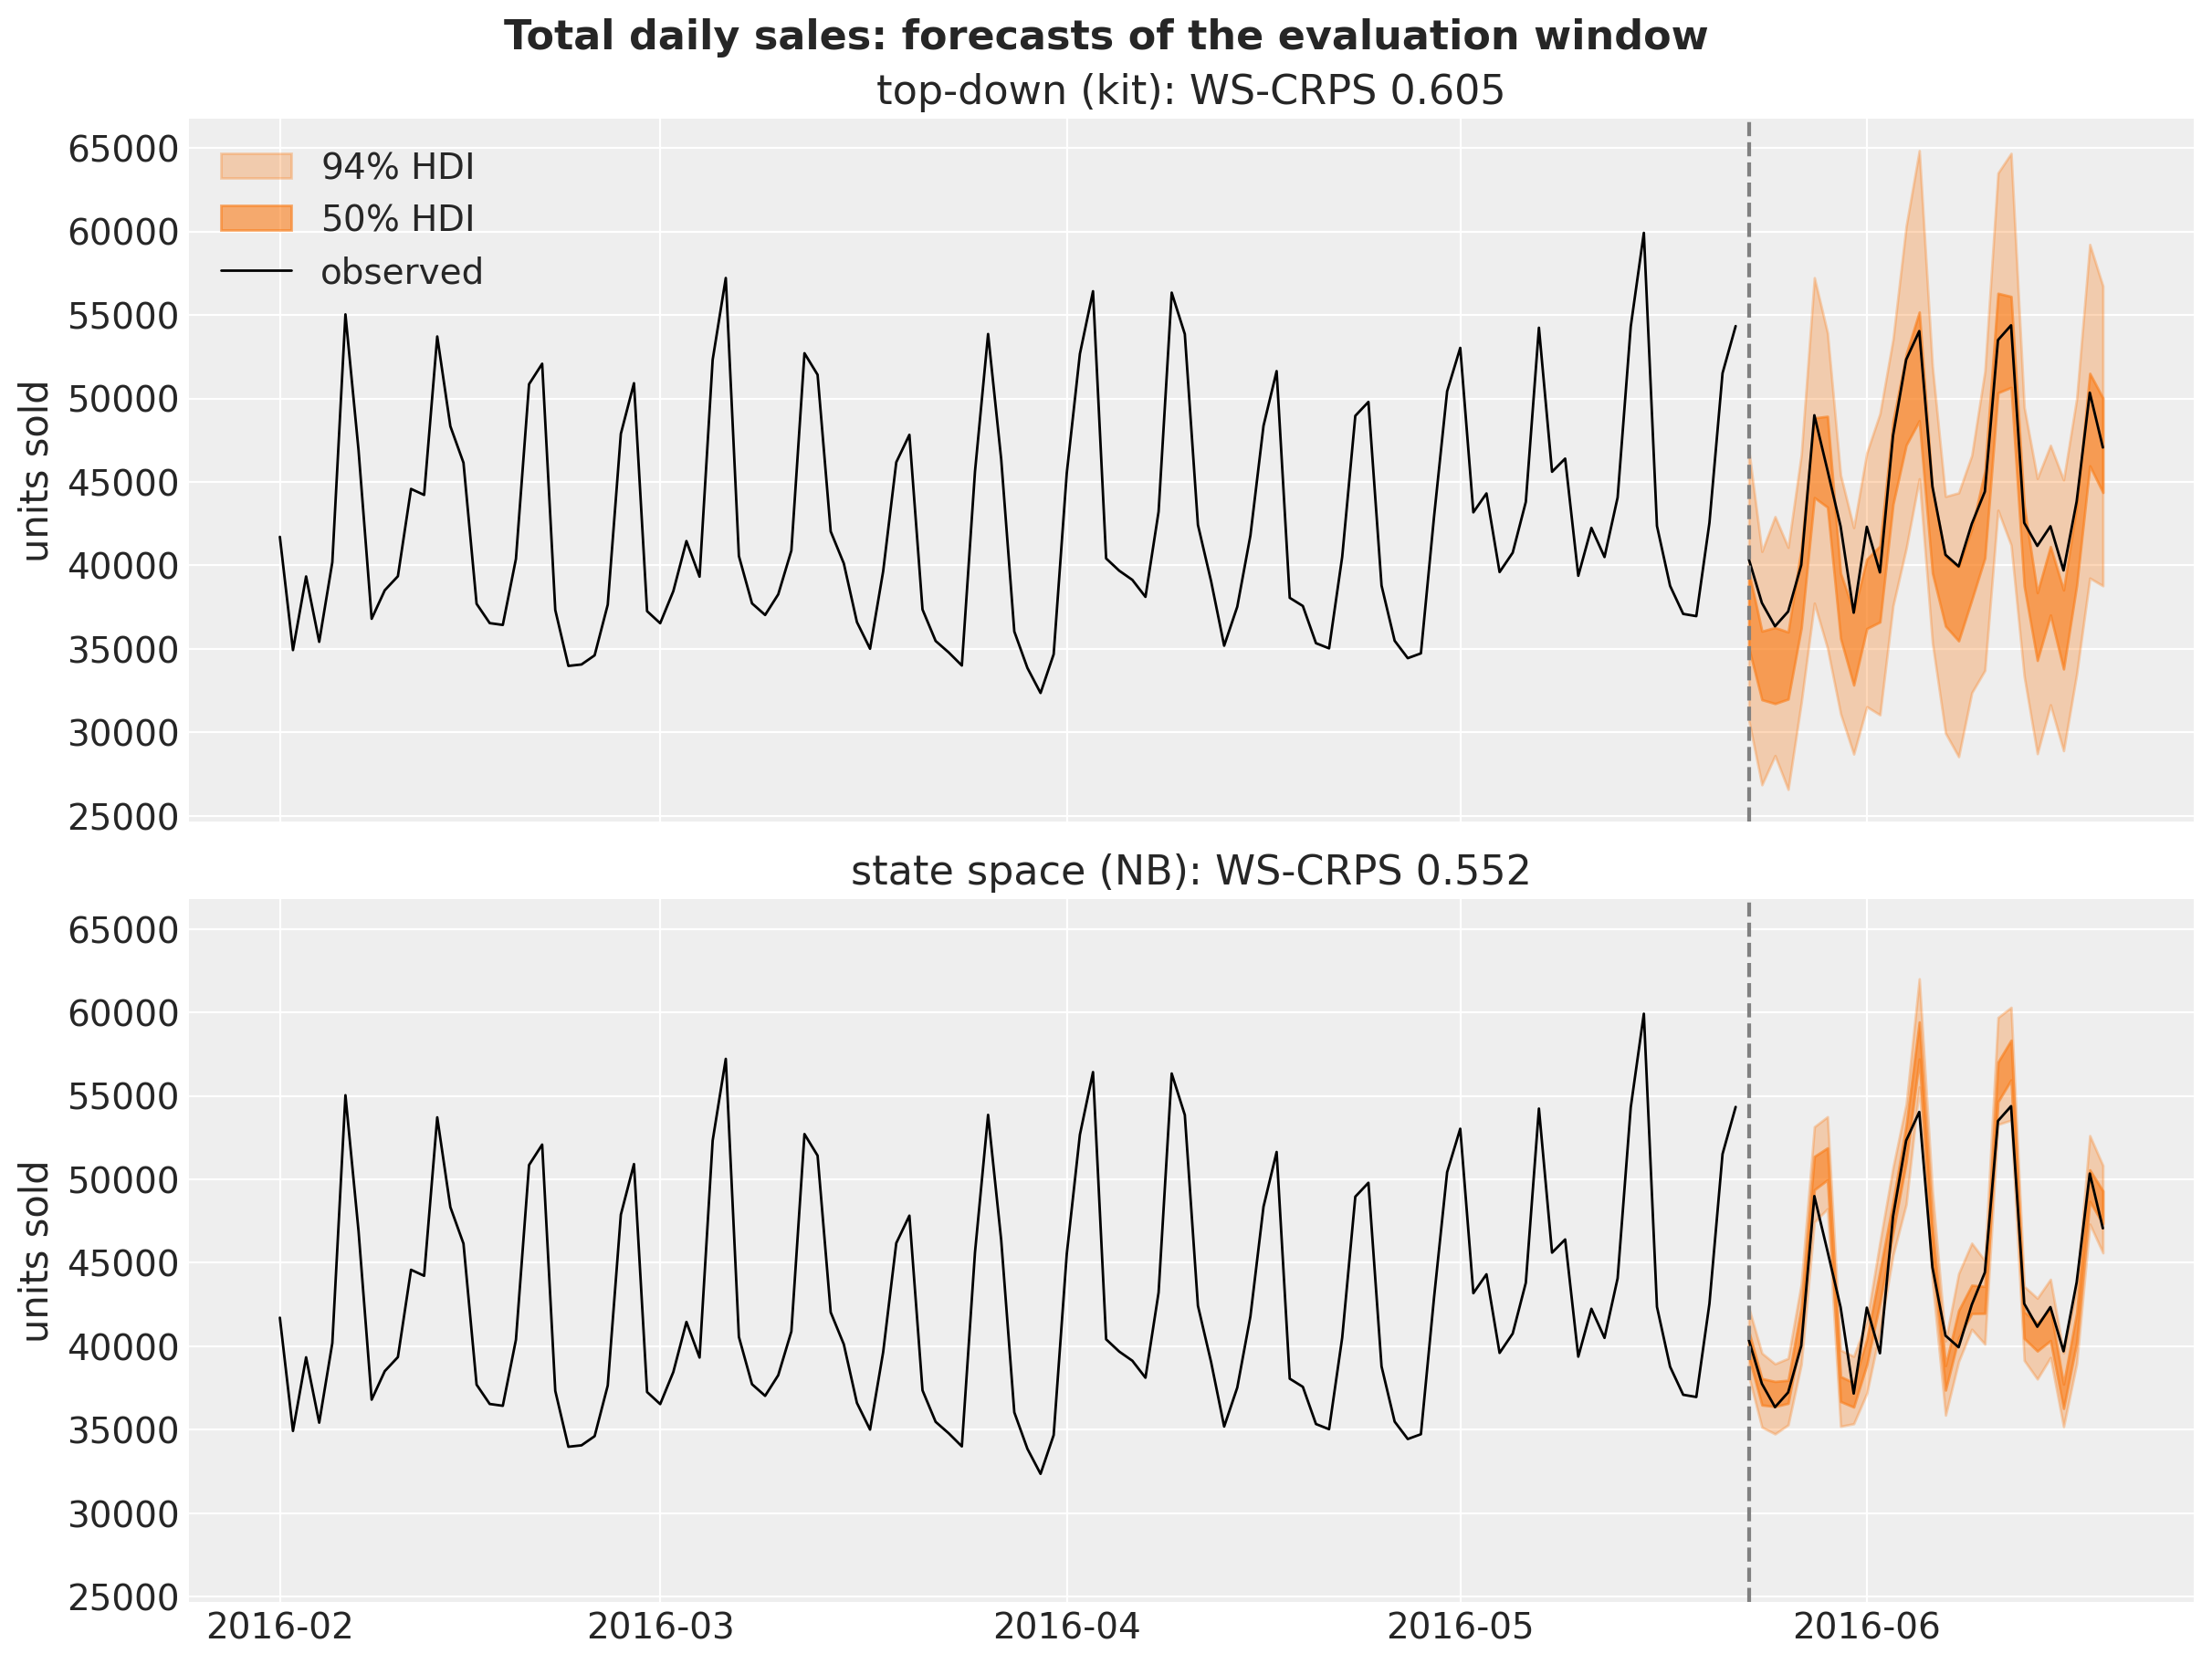

In [19]:
fig, axes = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 9), sharex=True, sharey=True, layout="constrained"
)
x_hist = date_num[plot_start:N_DAYS_TRAIN]
x_test = date_num[N_DAYS_TRAIN:N_DAYS]
y_total = sales_agg[:, 0]
for ax, (name, draws, ws) in zip(
    axes,
    [("top-down (kit)", level1_top, scores_top), ("state space (NB)", level1_final, scores_final)],
    strict=True,
):
    for prob, alpha in zip(HDI_PROBS, HDI_ALPHAS, strict=True):
        hdi = az.hdi(draws.T, prob=prob)
        ax.fill_between(
            x_test, hdi[:, 0], hdi[:, 1], color="C1", alpha=alpha, label=hdi_label(prob)
        )
    ax.plot(x_hist, y_total[plot_start:N_DAYS_TRAIN], color="black", lw=1, label="observed")
    ax.plot(x_test, y_total[N_DAYS_TRAIN:N_DAYS], color="black", lw=1)
    ax.axvline(split_date, color="gray", ls="--")
    ax.set(title=f"{name}: WS-CRPS {ws_crps_mean(ws):.3f}", ylabel="units sold")
axes[0].legend(loc="upper left")
axes[-1].xaxis_date()
fig.suptitle(
    "Total daily sales: forecasts of the evaluation window", fontsize=16, fontweight="bold"
);

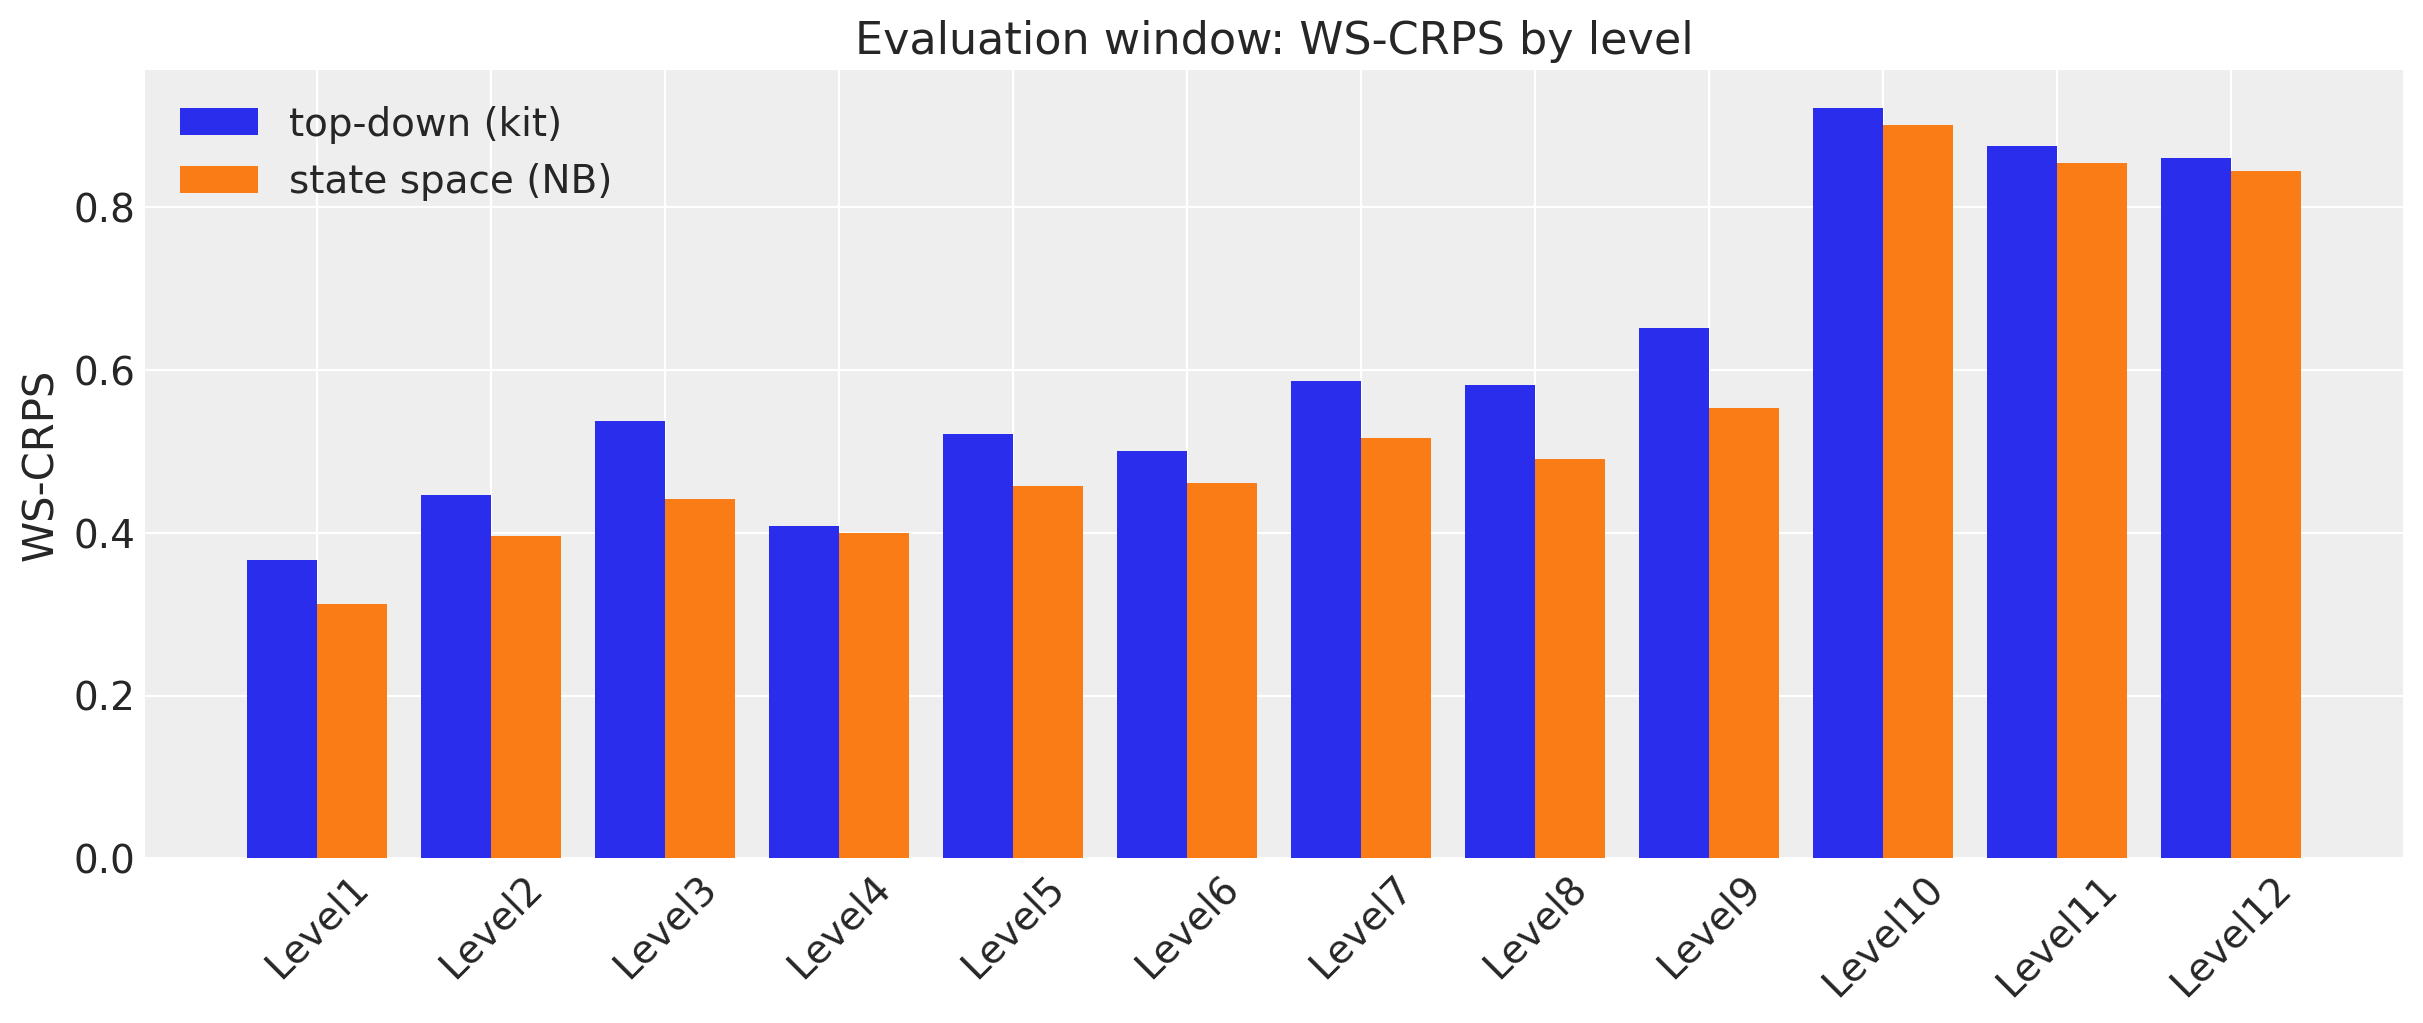

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(LEVELS))
width = 0.4
ax.bar(
    x - width / 2,
    holdout_table["top-down (kit)"][: len(LEVELS)].to_numpy(),
    width,
    label="top-down (kit)",
)
ax.bar(
    x + width / 2,
    holdout_table["state space (NB)"][: len(LEVELS)].to_numpy(),
    width,
    label="state space (NB)",
)
ax.set_xticks(x, list(LEVELS), rotation=45)
ax.set(title="Evaluation window: WS-CRPS by level", ylabel="WS-CRPS")
ax.legend();

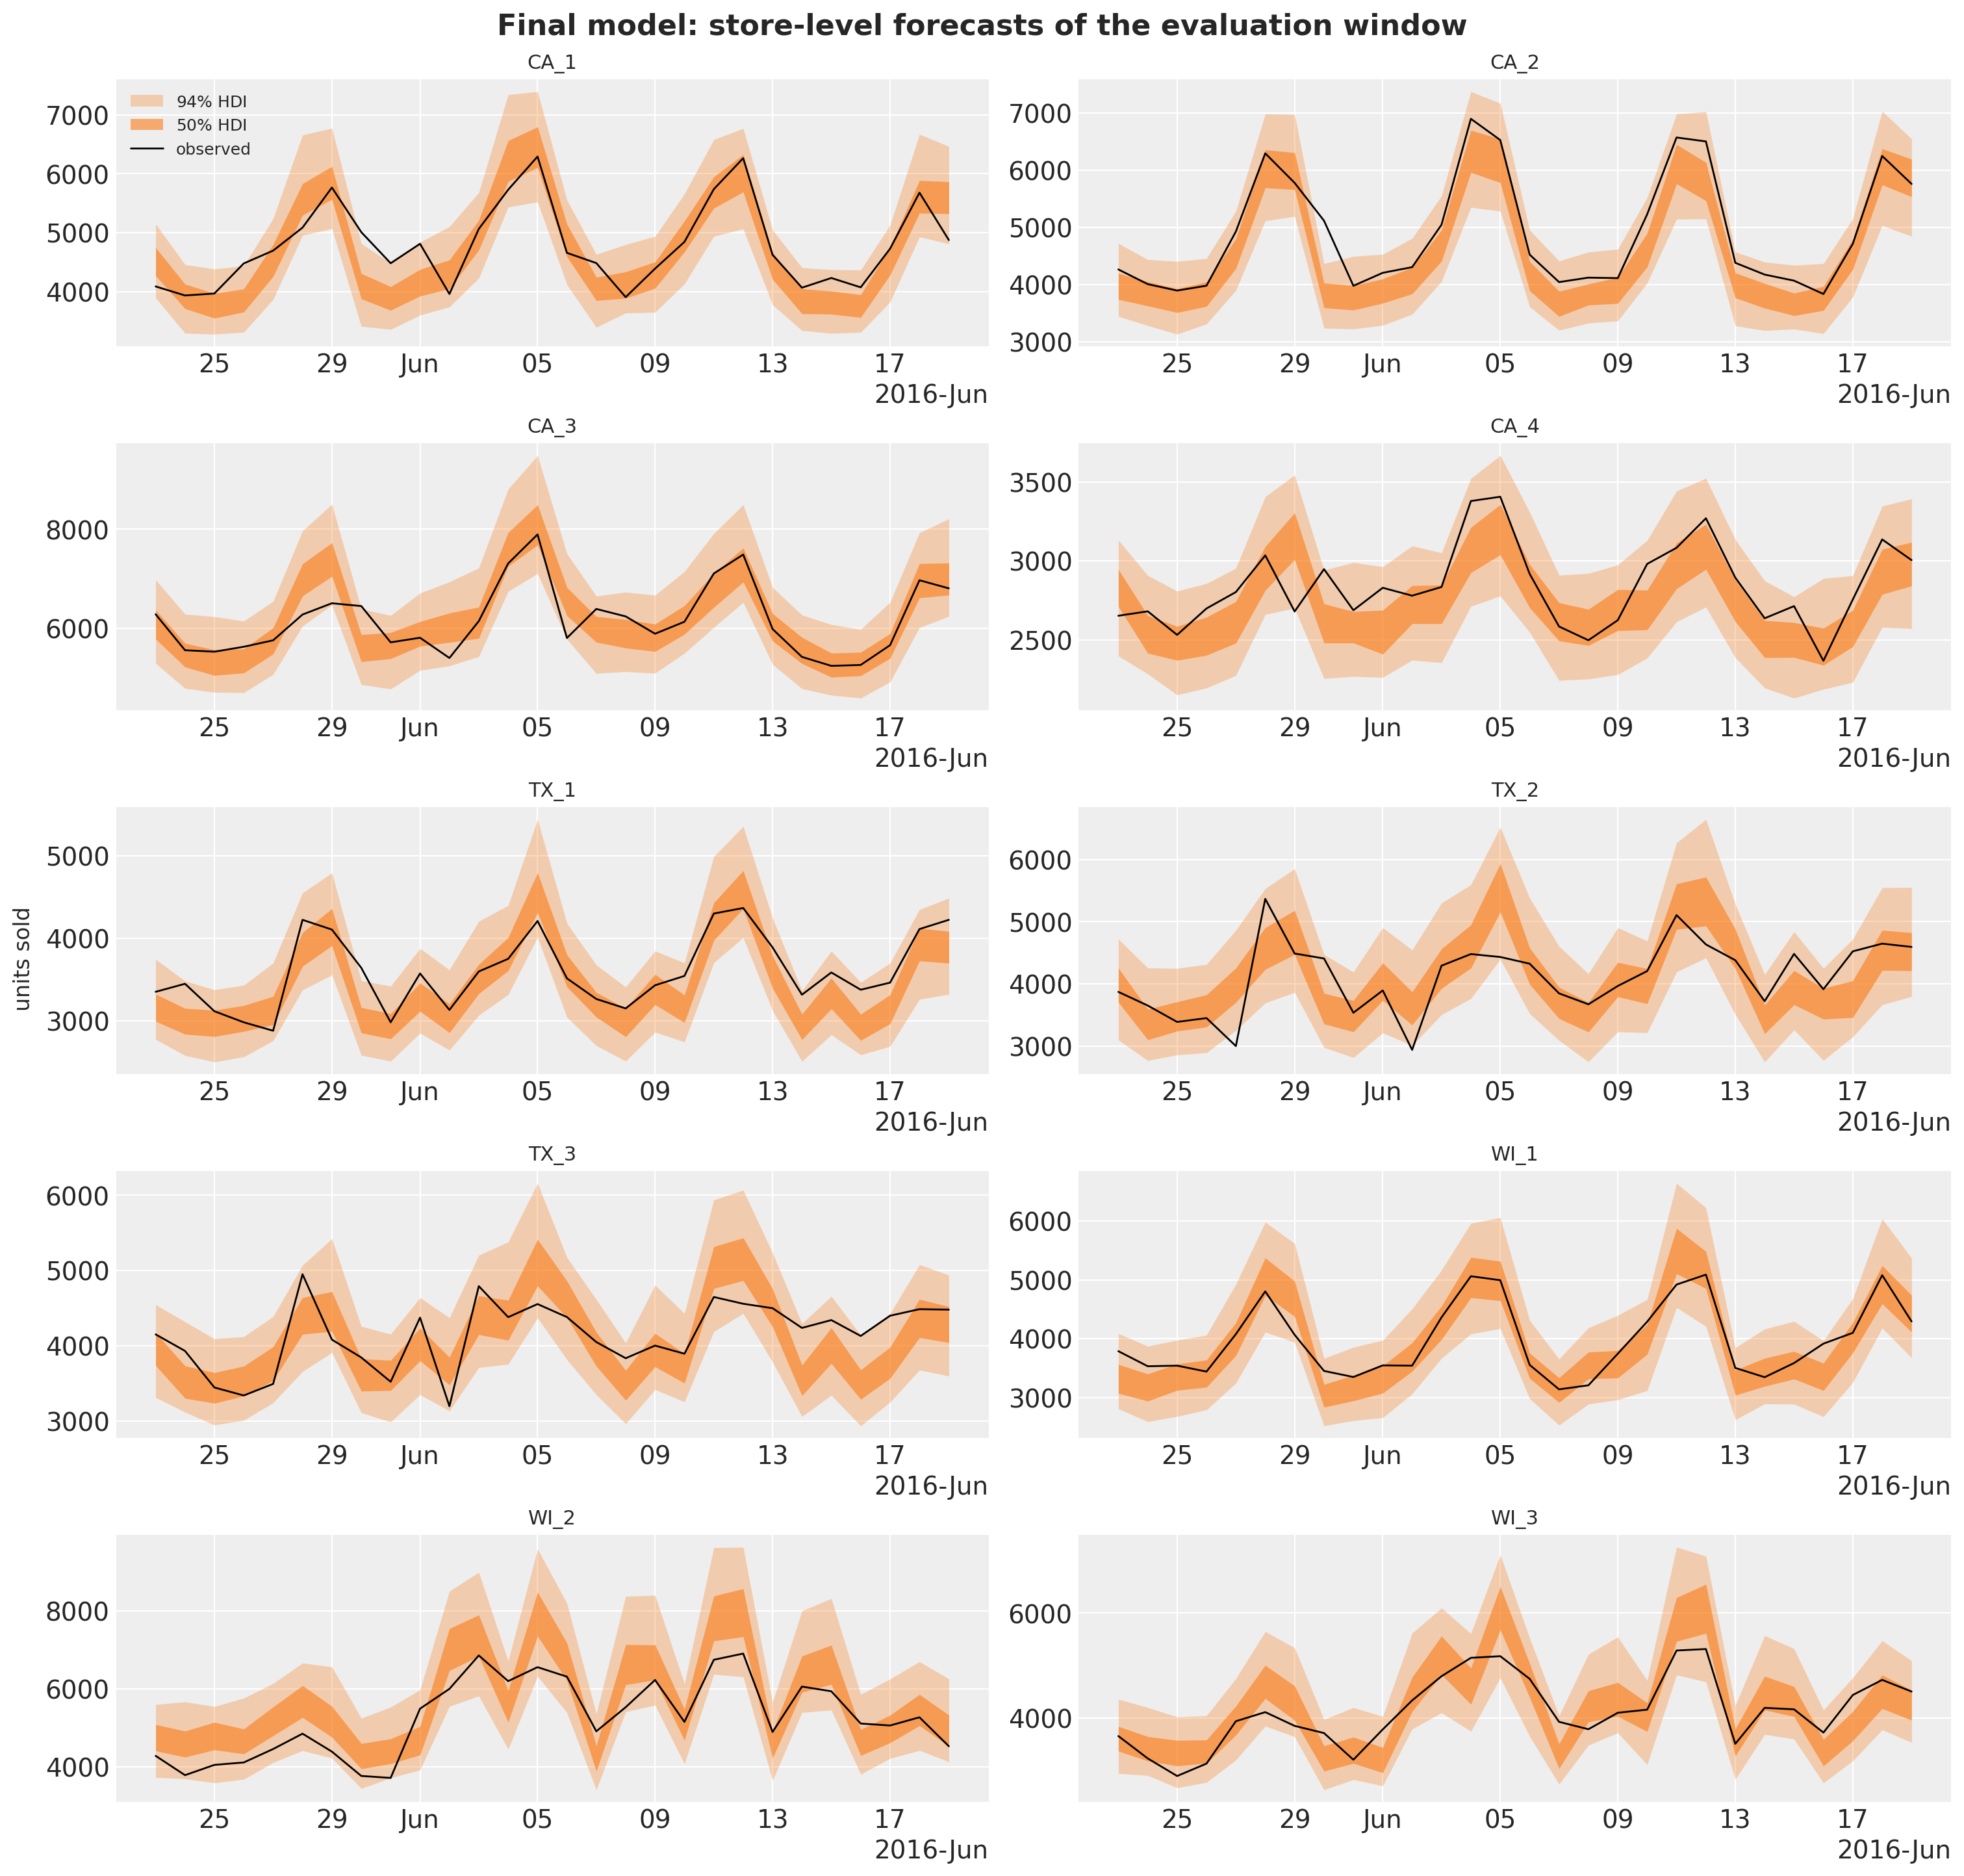

In [21]:
plot_series_panel(
    None,
    level3_final,
    sales_agg[N_DAYS_TRAIN:N_DAYS, level_slices["Level3"]],
    store_ids,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[N_DAYS_TRAIN:N_DAYS],
    ylabel="units sold",
    suptitle="Final model: store-level forecasts of the evaluation window",
    figsize=(15.0, 14.0),
)

## Cost

The state space model costs about two minutes per window on a 14-core M4
Pro CPU: 110 seconds for 3,000 SVI steps over 1,500-series minibatches
of two years of daily data (the number a full-batch model of 30,490
series would not reach) and 25 to 40 seconds to draw 250 to 500
bottom-level forecasts, against about ten seconds for the top-down
model. The whole notebook runs in about 12 minutes.

In [22]:
timing_table = (
    backtest_df.group_by("model", maintain_order=True)
    .agg(pl.col("walltime").mean().alias("backtest window, fit and forecast (s)"))
    .join(
        pl.DataFrame(
            {
                "model": ["top-down (kit)", "state space (NB)"],
                "evaluation window, fit and forecast (s)": [
                    time_top_fc,
                    time_final + time_fc_final,
                ],
            }
        ),
        on="model",
    )
    .sort("model", descending=True)
    .with_columns(pl.col(pl.Float64).round(0))
)
timing_table

## Discussion

The result is a single hierarchical model of all 30,490 M5 series that
beats the best starter-kit baseline by about $10\%$ in WS-CRPS on every
window, improves the competition’s pinball loss from 0.208 to 0.189 and,
unlike the baseline, carries calibrated uncertainty at the store and
store-department levels. It does so with plain NumPyro and the
`numpyro_forecast` building blocks: `Horizon.from_data` and `predict()`
for the train-and-forecast bookkeeping, explicit block and week plates
for the state space components, `AutoNormal` with `create_plates` and
`numpyro.subsample` for the minibatching, `backtest()` with a
`transform` and `per_window_metrics` for the hierarchy-wide score, and
`forecast()`, `predict_in_sample()` and `predictions_to_datatree()` for
the plots.

What the ablation and the backtest say about modeling this kind of data:

- **The level process is the model.** Centering the intercepts on the
  last-28-day level and letting an end-anchored block walk explain the
  past is what makes 30,490 independent item models competitive; every
  other component is a refinement. The block resolution matters: daily
  item walks and daily shared walks were tried during development and
  lost to the baseline, because a mean-field SVI fit lets a daily latent
  absorb noise as level and then projects it over the horizon.
- **Common shocks are for calibration, not for the score.** The weekly
  store shocks leave the CRPS unchanged and move the store-level $94\%$
  coverage from 0.70 to 0.95. A score that mixes twelve levels does not
  reward them much; a user of store-level forecasts does.
- **Level 1 is still too narrow.** The total of the M5 data has
  day-to-day variation that is neither an item’s nor a store’s; a
  state-level or total-level shock (or a non-mean-field guide over the
  origin levels) is the next component to try, and the coverage metric
  is the way to judge it.
- **The item levels are where the baseline holds.** A share of a
  well-fitted total with Poisson noise is a strong item forecast for the
  competition’s weights, which put $23\%$ of the level-12 weight on the
  7,772 series that sold on fewer than one day in five of the last
  training year; a hurdle or zero-inflated likelihood for those series
  is the other open item.

Two fairness notes. The model uses the `saled` flag over the horizon,
that is, it knows which items are listed during the evaluation days, as
the kit models do through their shares; and the calendar (weekdays, SNAP
days, events) is known in advance, so nothing else leaks. The reference
price is computed on the first 1,843 days, before any backtest origin,
and the price channel is not used by the model anyway.

## References

- [Pyro M5 Starter
  Kit](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit): the three
  baseline models and the WS-CRPS harness ported in the [M5 baselines
  notebook](m5_forecasting.html).
- [Makridakis, Spiliotis and Assimakopoulos (2022), *The M5 uncertainty
  competition: results, findings and
  conclusions*](https://doi.org/10.1016/j.ijforecast.2021.10.009), for
  the WSPL metric and the competition results.
- [NumPyro: stochastic variational inference with
  subsampling](https://num.pyro.ai/en/stable/svi.html), the `subsample`
  and `create_plates` mechanics used here.